In [1]:
# EDA – fact_actividades_provincia_enriquecida
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math


df_actividades = pd.read_csv("../../data/clean/fact_actividades_provincia_enriquecida.csv",
                      encoding="utf-8-sig"
                      )
df_muni = pd.read_csv("../../data/clean/dim_municipio_final.csv",
                      encoding="utf-8-sig"
                      )
df_geo = pd.read_csv("../../data/clean/dim_geografia_municipio_osm.csv",
                      encoding="utf-8-sig"
                      )
df_ccaa = pd.read_csv("../../data/clean/dim_ccaa_base.csv",
                      encoding="utf-8-sig"
                      )
df_prov = pd.read_csv("../../data/clean/dim_provincia_base.csv",
                      encoding="utf-8-sig"
                      )
# Convertir IDs geográficos a tipo categórico (string)
df_muni["id_provincia"] = df_muni["id_provincia"].astype(str)
df_muni["id_ccaa"] = df_muni["id_ccaa"].astype(str)
df_ccaa["id_ccaa"] = df_ccaa["id_ccaa"].astype(str)
df_prov["id_provincia"] = df_prov["id_provincia"].astype(str).str.zfill(2)
# Convertir IDs geográficos a tipo categórico (string)
df_actividades["id_ccaa"] = df_actividades["id_ccaa"].astype(str)
df_actividades["id_provincia"] = df_actividades["id_provincia"].astype(str)
# Opcional: también id_pais si aplica
df_actividades["id_pais"] = df_actividades["id_pais"].astype(str)

In [2]:
from pathlib import Path
import os
try:
    BASE_DIR = Path(__file__).resolve().parents[2]
except NameError:
    # Si estás en notebook o entorno interactivo
    BASE_DIR = Path(os.getcwd())

BASE_DIR = Path(r"C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM")
ASSETS_DIR = BASE_DIR / "assets"
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Configuración de Parametros

TOP_N = 10
PALETA_HEAT = "YlGnBu"

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

## Diccionario de variables (resumen)

El dataset está a **nivel provincia–mes–producto–subcategoría** (con categoría mapeada) e incluye claves territoriales y métricas económicas y de reputación.


In [4]:
df_actividades.head()

,id_actividad,id_pais,id_ccaa,id_provincia,mes,categoria,producto,subcategoria,comunidad_autonoma,provincia,gasto_total_promedio,precio_medio_entrada_promedio,valoracion_por_categoria_promedio,valoracion_general_promedio,total_opiniones_categoria_promedio,hay_valoracion
0,1,ES,1,4,1,paisaje naturaleza,actividades,actividades infantiles,andalucia,almeria,4123.00,87.50,4.32,4.19,23376,True
1,2,ES,1,11,1,paisaje naturaleza,actividades,actividades infantiles,andalucia,cadiz,95390.25,2151.75,4.27,4.26,12350,True
2,3,ES,1,14,1,paisaje naturaleza,actividades,actividades infantiles,andalucia,cordoba,147685.50,1044.50,4.32,4.29,3767,True
3,4,ES,1,18,1,paisaje naturaleza,actividades,actividades infantiles,andalucia,granada,67115.00,601.67,4.52,4.37,18492,True
4,5,ES,1,21,1,paisaje naturaleza,actividades,actividades infantiles,andalucia,huelva,25675.00,499.00,4.12,4.11,8396,True


## Tipo de dato y nulos

In [5]:
# Información general
df_actividades.info()

# Tabla estructurada tipo diccionario de datos
eda_structure = pd.DataFrame({
    "Column Name": df_actividades.columns,
    "Data Type": df_actividades.dtypes.values,
    "NULLs allowed": ["Y" if df_actividades[c].isna().any() else "N" for c in df_actividades.columns],
    "NULL %": [round(df_actividades[c].isna().mean()*100, 2) for c in df_actividades.columns]
})

eda_structure

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3609 entries, 0 to 3608
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   id_actividad                        3609 non-null   int64  
 1   id_pais                             3609 non-null   object 
 2   id_ccaa                             3609 non-null   object 
 3   id_provincia                        3609 non-null   object 
 4   mes                                 3609 non-null   int64  
 5   categoria                           3609 non-null   object 
 6   producto                            3609 non-null   object 
 7   subcategoria                        3609 non-null   object 
 8   comunidad_autonoma                  3609 non-null   object 
 9   provincia                           3609 non-null   object 
 10  gasto_total_promedio                3609 non-null   float64
 11  precio_medio_entrada_promedio       3609 no

,Column Name,Data Type,NULLs allowed,NULL %
0,id_actividad,int64,N,0.0
1,id_pais,object,N,0.0
2,id_ccaa,object,N,0.0
3,id_provincia,object,N,0.0
4,mes,int64,N,0.0
5,categoria,object,N,0.0
6,producto,object,N,0.0
7,subcategoria,object,N,0.0
8,comunidad_autonoma,object,N,0.0
9,provincia,object,N,0.0


El dataset final presenta una estructura consistente con un modelo de tipo fact table a nivel provincial, con las siguientes características:
id_actividad funciona como clave primaria (PK) y no presenta duplicados.
id_provincia e id_ccaa actúan como claves foráneas (FK) correctamente tipificadas.
mes se encuentra como variable entera, permitiendo análisis temporal.
Las métricas económicas (gasto_total_promedio, precio_medio_entrada_promedio) están correctamente tipificadas como float64.
Las métricas de reputación están en formato numérico y correctamente escaladas.
hay_valoracion se encuentra como tipo booleano (bool), garantizando integridad lógica.
Se observa que aproximadamente el 1.16% de los registros presenta valores nulos en:
valoracion_por_categoria_promedio
valoracion_general_promedio
total_opiniones_categoria_promedio
La ausencia de valoraciones no corresponde a errores de procesamiento, sino a falta de información disponible en la fuente original.

In [6]:
df_actividades["id_actividad"].min()
df_actividades["id_actividad"].max()

np.int64(3609)

In [7]:
df_actividades["id_pais"].str.len().max()

np.int64(2)

In [8]:
df_actividades["id_ccaa"].str.len().max()

np.int64(2)

In [9]:
df_actividades["id_provincia"].str.len().max()

np.int64(2)

In [10]:
df_actividades["mes"].min()
df_actividades["mes"].max()

np.int64(12)

In [11]:
df_actividades["categoria"].str.len().max()

np.int64(18)

In [12]:
df_actividades["producto"].str.len().max()

np.int64(12)

In [13]:
df_actividades["subcategoria"].str.len().max()

np.int64(23)

In [14]:
df_actividades["comunidad_autonoma"].str.len().max()

np.int64(26)

In [15]:
df_actividades["provincia"].str.len().max()

np.int64(22)

In [16]:
df_actividades["gasto_total_promedio"].min()
df_actividades["gasto_total_promedio"].max()


np.float64(5578091.0)

In [17]:
col = "gasto_total_promedio"

# máximo de decimales presentes (como texto)
max_dec = (
    df_actividades[col]
    .dropna()
    .astype(str)
    .str.split(".", n=1)
    .str[1]
    .fillna("")
    .str.len()
    .max()
)

max_dec

np.int64(2)

In [18]:
df_actividades["precio_medio_entrada_promedio"].min()
df_actividades["precio_medio_entrada_promedio"].max()

np.float64(47799.0)

In [19]:
col1 = "precio_medio_entrada_promedio"

# máximo de decimales presentes (como texto)
max_dec = (
    df_actividades[col]
    .dropna()
    .astype(str)
    .str.split(".", n=1)
    .str[1]
    .fillna("")
    .str.len()
    .max()
)

max_dec

np.int64(2)

In [20]:
df_actividades["valoracion_por_categoria_promedio"].min()
df_actividades["valoracion_por_categoria_promedio"].max()

np.float64(5.0)

In [21]:
col2 = "precio_medio_entrada_promedio"

# máximo de decimales presentes (como texto)
max_dec = (
    df_actividades[col]
    .dropna()
    .astype(str)
    .str.split(".", n=1)
    .str[1]
    .fillna("")
    .str.len()
    .max()
)

max_dec

np.int64(2)

In [22]:
df_actividades["valoracion_general_promedio"].min()
df_actividades["valoracion_general_promedio"].max()

np.float64(4.43)

In [23]:
col3 = "valoracion_general_promedio"

# máximo de decimales presentes (como texto)
max_dec = (
    df_actividades[col]
    .dropna()
    .astype(str)
    .str.split(".", n=1)
    .str[1]
    .fillna("")
    .str.len()
    .max()
)

max_dec

np.int64(2)

In [24]:
df_actividades["total_opiniones_categoria_promedio"].min()
df_actividades["total_opiniones_categoria_promedio"].max()

np.int64(732080)

In [25]:
col4 = "total_opiniones_categoria_promedio"

# máximo de decimales presentes (como texto)
max_dec = (
    df_actividades[col]
    .dropna()
    .astype(str)
    .str.split(".", n=1)
    .str[1]
    .fillna("")
    .str.len()
    .max()
)

max_dec

np.int64(2)

In [26]:
df_actividades["hay_valoracion"].astype(str).str.len().unique()

array([4, 5])

1) Longitud de variables tipo texto
El análisis de longitud máxima de los campos categóricos arrojó los siguientes resultados:
id_pais → longitud máxima observada: 2 caracteres
categoria → longitud máxima observada: 18 caracteres
producto → longitud máxima observada: 12 caracteres
subcategoria → longitud máxima observada: 23 caracteres
comunidad_autonoma → longitud máxima observada: 26 caracteres
provincia → longitud máxima observada: 22 caracteres
El campo id_pais corresponde a un código ISO-2, por lo que su longitud fija de 2 caracteres confirma su modelado como CHAR(2).
El campo id_ccaa corresponde a una lo que su longitud fija de 2 caracteres confirma su modelado como CHAR(2).
El campo id_provincia corresponde a una lo que su longitud fija de 2 caracteres confirma su modelado como CHAR(2).
Las variables categóricas presentan longitudes moderadas y controladas, siendo la mayor observada de 26 caracteres en comunidad_autonoma. Esto indica que una definición tipo VARCHAR(40) es más que suficiente, evitando sobredimensionamiento innecesario y optimizando almacenamiento.
En términos estructurales, el dataset no presenta cadenas extensas ni campos desnormalizados, lo cual confirma una correcta estandarización durante el proceso ETL.
2) Variables económicas (gasto y precio)
Los valores observados fueron:
gasto_total_promedio
máximo observado ≈ 5,578,091
decimales máximos observados: 2
precio_medio_entrada_promedio
máximo observado ≈ 47,799
decimales máximos observados: 2
Esto confirma que:
Las métricas económicas mantienen precisión de hasta dos decimales.
No existen valores con precisión extendida innecesaria.
El rango máximo de gasto supera los cinco millones, lo que exige un tipo con capacidad suficiente.
Dado el rango y naturaleza de los datos:
NUMERIC(12,2) es adecuado para gasto_total_promedio
Permite valores hasta ±9,999,999,999.99
Cubre completamente el rango observado.
NUMERIC(10,2) es suficiente para precio_medio_entrada_promedio
Se recomienda el uso de NUMERIC en lugar de FLOAT para evitar errores de precisión binaria en métricas económicas.
3) Variables de reputación
El análisis mostró:
valoracion_por_categoria_promedio
rango observado: 4.00 – 5.00
decimales máximos: 2
valoracion_general_promedio
rango observado: 4.00 – 4.43
decimales máximos: 2
total_opiniones_categoria_promedio
máximo observado ≈ 732,080
sin decimales reales significativos
Esto confirma que:
Las valoraciones se mantienen dentro del rango [0–5].
Una precisión de dos decimales es suficiente.
NUMERIC(3,2) es adecuado para variables de valoración.
INTEGER es suficiente para total_opiniones_categoria_promedio.
El comportamiento observado muestra baja dispersión en ratings, lo que puede interpretarse como un sesgo positivo típico en plataformas turísticas.

4) Variable booleana
El campo hay_valoracion se encuentra correctamente tipificado como booleano.
El análisis mostró únicamente dos valores posibles (TRUE / FALSE), confirmando su idoneidad como BOOLEAN en PostgreSQL.
No requiere definición de longitud ni precisión.

## Validación estructural del modelo (PK/FK)
Se valida unicidad de la PK (`id_actividad`), completitud de FKs (`id_provincia`, `id_ccaa`) y rango de `mes` (1–12).

In [27]:
# PK
dup_pk = df_actividades["id_actividad"].duplicated().sum()

# FK nulos
null_fk = df_actividades[["id_pais","id_ccaa","id_provincia"]].isna().sum()

# Mes
mes_min, mes_max = df_actividades["mes"].min(), df_actividades["mes"].max()
mes_invalid = df_actividades[~df_actividades["mes"].between(1,12)].shape[0]

dup_pk, null_fk, (mes_min, mes_max, mes_invalid)

(np.int64(0),
 id_pais         0
 id_ccaa         0
 id_provincia    0
 dtype: int64,
 (np.int64(1), np.int64(12), 0))

No existen valores nulos en claves foráneas.
No existen filas huérfanas.
El rango temporal es válido (mes calendario).
No hay valores fuera de rango (0, 13, negativos).
No hay registros sin mes.
El análisis de completitud de claves mostró 0 valores nulos en las variables id_pais, id_ccaa e id_provincia, lo que confirma la correcta integración entre la tabla de hechos y las dimensiones territoriales.
Asimismo, la variable mes presenta un rango válido entre 1 y 12, sin valores fuera de rango ni registros nulos. Esto valida la coherencia temporal del dataset y su aptitud para análisis estacional.

## Valores nulos y cobertura de valoraciones
Las valoraciones provienen de la integración con recursos turísticos; por ello puede existir cobertura parcial por combinación provincia–categoría.

In [28]:
na = df_actividades.isna().sum().sort_values(ascending=False)
na[na>0]

Series([], dtype: int64)

In [29]:
# ¿Dónde faltan valoraciones?
sin_val = df_actividades[df_actividades["hay_valoracion"] == False]
sin_val[["id_ccaa","comunidad_autonoma","id_provincia","provincia","categoria"]].drop_duplicates().head(20), sin_val.shape[0]

(     id_ccaa    comunidad_autonoma id_provincia           provincia  \
 54        11           extremadura            6             badajoz   
 157       18                 ceuta           51               ceuta   
 364       11           extremadura            6             badajoz   
 499       18                 ceuta           51               ceuta   
 1211       7       castilla y leon           49              zamora   
 1504      10  comunitat valenciana           12  castellon/castello   
 1507      12               galicia           32             ourense   
 1842      16            pais vasco            1         araba/alava   
 
             categoria  
 54          servicios  
 157    paisaje urbano  
 364   comida y bebida  
 499     vida nocturna  
 1211  comida y bebida  
 1504  comida y bebida  
 1507  comida y bebida  
 1842            otros  ,
 42)

El análisis de completitud evidenció que las variables de reputación presentan 42 valores nulos en valoracion_por_categoria_promedio, valoracion_general_promedio y total_opiniones_categoria_promedio. Esta coincidencia exacta entre las tres métricas sugiere que la ausencia no proviene de errores de conversión, sino de una falta de correspondencia en el enriquecimiento (merge) o de la inexistencia de registros de reputación para determinadas combinaciones territoriales y de categoría.
En la inspección de casos (hay_valoracion = False) se identificaron combinaciones específicas como Ceuta–Ceuta, Extremadura–Badajoz, Castilla y León–Zamora, Comunitat Valenciana–Castellón/Castelló, Galicia–Ourense y País Vasco–Araba/Álava, entre otras. Estas filas mantienen datos económicos (gasto y precio), pero no cuentan con información reputacional asociada.
Se decide mantener estos campos como NULL para preservar la semántica correcta (“dato no disponible”), incorporando hay_valoracion como indicador explícito. Esto permite a la capa analítica diferenciar entre “sin datos” y “baja valoración”, evitando sesgos en promedios y comparativas entre provincias o categorías.

## Estadísticos descriptivos
Se resumen métricas de gasto, precio y valoraciones para identificar escala, dispersión y presencia de valores extremos.

In [30]:
num_cols = [
    "gasto_total_promedio",
    "precio_medio_entrada_promedio",
    "valoracion_por_categoria_promedio",
    "valoracion_general_promedio",
    "total_opiniones_categoria_promedio"
]

In [31]:
df_actividades[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
gasto_total_promedio,3609.0,178811.907490,341642.448160,49.0,13024.00,63827.00,196873.90,5578091.00
precio_medio_entrada_promedio,3609.0,1335.388523,1890.121841,25.0,531.69,952.00,1453.71,47799.00
valoracion_por_categoria_promedio,3609.0,4.135104,0.549944,0.0,4.01,4.22,4.37,5.00
valoracion_general_promedio,3609.0,4.189978,0.465487,0.0,4.17,4.25,4.31,4.43
total_opiniones_categoria_promedio,3609.0,36283.186201,80549.766826,0.0,1293.00,6159.00,39053.00,732080.00


Distribución fuertemente sesgada a la derecha
Presencia de valores extremos muy altos
Alta concentración económica en ciertas provincias/productos
Media > mediana
Máximo extremadamente alto comparado con el Q3 (1453)
Hay algunos productos con precios muy elevados que elevan la media.
Concentración fuerte entre 4 y 4.4
Baja variabilidad
Existe un valor mínimo bajo (1.93), que podría ser caso puntual
Sistema de reputación con sesgo positivo generalizado.
Concentración fuerte entre 4 y 4.4
Baja variabilidad
Existe un valor mínimo bajo (1.93), que podría ser caso puntual
Sistema de reputación con sesgo positivo generalizado.
Diferencias muy pequeñas entre provincias
Muy poca dispersión real
Es casi constante comparada con gasto o precio.

La fuerte diferencia entre media y mediana en gasto total indica que:
Existen polos económicos dominantes
El turismo no está distribuido de manera homogénea
Aunque el precio tiene dispersión, no alcanza la magnitud del gasto.
El gasto total no depende solo del precio de entrada.
Puede estar influenciado por volumen de actividad, popularidad, o mezcla de categorías.
Valoraciones concentradas en 4–4.4 indican:
Alta satisfacción general.
Baja capacidad discriminativa entre provincias.
Desde perspectiva analítica:
El rating por sí solo no es suficiente para ranking diferencial.
Debe combinarse con volumen de opiniones.
El máximo de 732,080 opiniones indica:
Algunas actividades dominan la conversación digital.
Posible efecto “superstar”.
Esto puede utilizarse para:
Identificar hubs turísticos.
Detectar provincias con alto posicionamiento digital.

## Estacionalidad (proxy) por mes
El campo `mes` se utiliza como aproximación a estacionalidad. Se analiza cómo varían el gasto y el precio promedio a lo largo del año.

In [32]:
tmp_mes = df_actividades.groupby("mes", as_index=False).agg(
    gasto_promedio=("gasto_total_promedio","mean"),
    precio_promedio=("precio_medio_entrada_promedio","mean"),
    registros=("id_actividad","count")
).sort_values("mes")

tmp_mes

,mes,gasto_promedio,precio_promedio,registros
0,1,228963.288745,1096.154207,271
1,2,183875.099307,1128.604927,274
2,3,184652.864965,1192.257797,286
3,4,198800.308728,1379.614664,283
4,5,188445.406403,1389.339568,278
5,6,141218.641570,1471.887645,293
6,7,143945.370000,1581.803322,307
7,8,149737.903754,1499.314757,309
8,9,156898.405590,1564.253634,322
9,10,172728.534307,1179.687611,339


Gasto promedio:
Máximo: diciembre (~236,253)
Segundo pico: enero (~228,963)
Mínimo: junio (~141,219)
Caída fuerte entre mayo → junio
Recuperación progresiva desde septiembre
Precio promedio:
Aumenta progresivamente hasta julio (~1,582)
Se mantiene alto en agosto y septiembre
Disminuye en octubre
No alcanza su máximo en diciembre
Registros:
Aumentan hacia el final del año
Máximo en noviembre (340)
Mínimo en enero (271)

Durante verano:
Precio es más alto (junio–septiembre)
Pero el gasto promedio es relativamente bajo comparado con diciembre
Esto sugiere que el gasto total no depende exclusivamente del precio unitario.
Diciembre presenta:
El mayor gasto promedio del año
Precio moderado
Registros relativamente altos
Posible efecto Navidad / turismo festivo.
En julio y agosto:
Precio máximo del año
Gasto promedio relativamente bajo
Desde septiembre hasta diciembre:
Gasto aumenta consistentemente
Precio se modera
Registros aumentan
Indica posible segunda temporada alta (otoño-invierno).
Se observa que:
No hay correlación lineal clara mes a mes.
Los meses con mayor precio no son necesariamente los de mayor gasto.

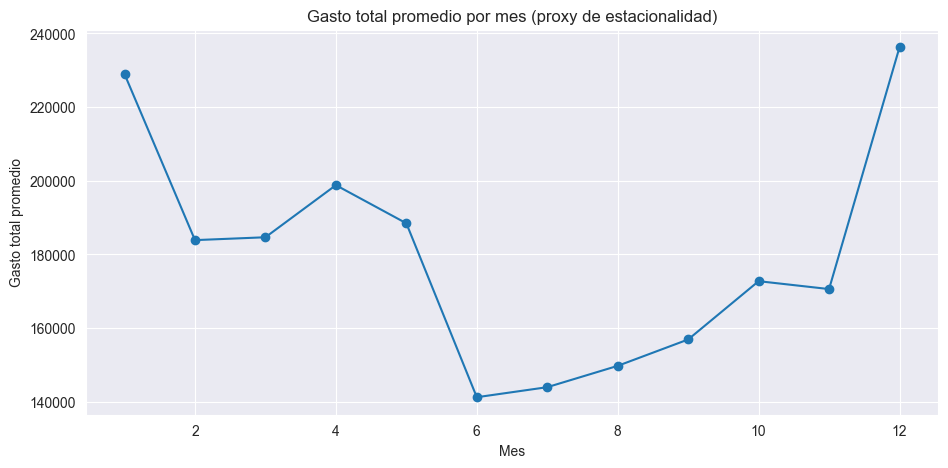

In [88]:
plt.figure()
plt.plot(tmp_mes["mes"], tmp_mes["gasto_promedio"], marker="o")
plt.xlabel("Mes")
plt.ylabel("Gasto total promedio")
plt.title("Gasto total promedio por mes (proxy de estacionalidad)")
# Guardar en assets

plt.savefig(ASSETS_DIR / "Gasto total promedio por mes.png", dpi=300)
plt.show()
plt.close()

Se identifican dos picos claros:
Enero
Diciembre
Esto sugiere:
Temporada alta invernal
Impacto de periodos festivos (Navidad / Año Nuevo)
Junio representa el punto más bajo del año.
Interpretación posible:
Transición entre temporadas.
Menor concentración de turismo cultural.
Inicio de periodo estival con cambio de patrón de consumo.
Desde agosto el gasto aumenta de manera sostenida hasta diciembre.
Posible efecto:
Turismo urbano
Eventos culturales
Temporada de congresos
Turismo navideño
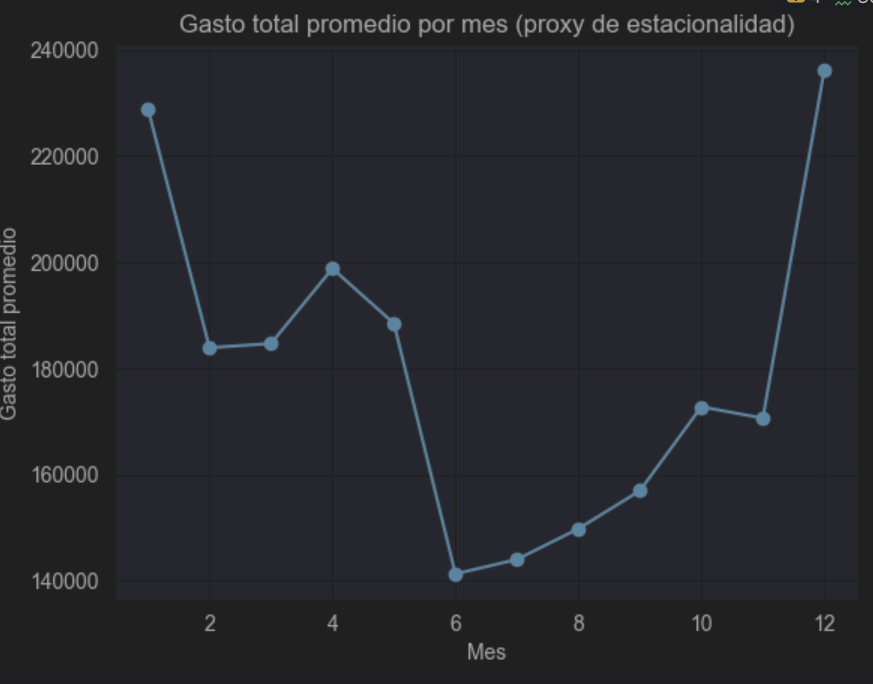

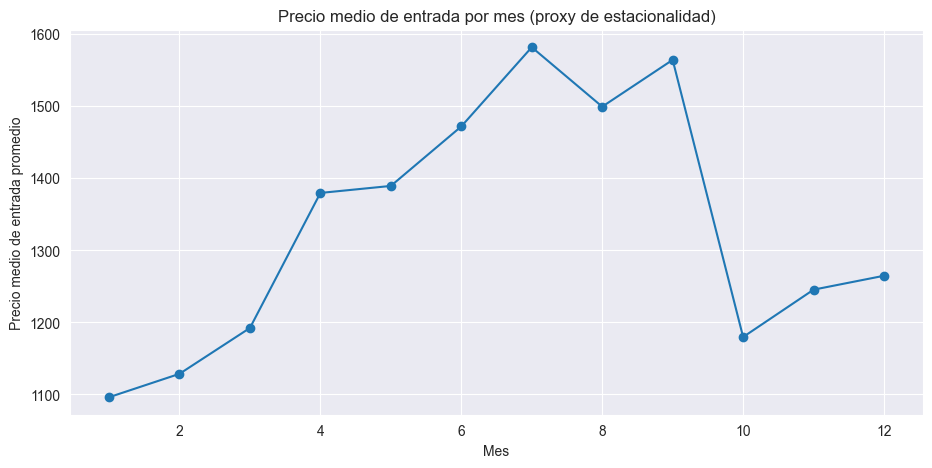

In [89]:
plt.figure()
plt.plot(tmp_mes["mes"], tmp_mes["precio_promedio"], marker="o")
plt.xlabel("Mes")
plt.ylabel("Precio medio de entrada promedio")
plt.title("Precio medio de entrada por mes (proxy de estacionalidad)")
# Guardar en assets

plt.savefig(ASSETS_DIR / "Precio medio de entrada por mes.png", dpi=300)
plt.show()
plt.close()

El precio presenta una curva clásica de temporada alta en verano:
Aumento progresivo hacia julio.
Pico en julio.
Descenso post-verano.
Esto es coherente con dinámica turística tradicional.
A diferencia del gasto:
Diciembre tiene el mayor gasto.
Pero no el mayor precio.
Esto indica:
El aumento del gasto en diciembre no se explica por precios altos, sino por volumen o intensidad de actividad.
Octubre muestra el ajuste más fuerte.
Posible explicación:
Fin de temporada alta.
Reajuste de tarifas.
Menor demanda.
El precio responde a temporada alta estival.
El gasto responde a más de un factor (volumen, eventos, festividades).

## Relación entre tipo de producto y gasto / precio promedio
Se evalúa si `producto` influye en el gasto total y el precio medio. Además, se incorpora el conteo de registros para contextualizar la comparación.

In [35]:
prod = df_actividades.groupby("producto", as_index=False).agg(
    gasto_total_promedio=("gasto_total_promedio","mean"),
    precio_medio_entrada_promedio=("precio_medio_entrada_promedio","mean"),
    total_registros=("id_actividad","count")
).sort_values("gasto_total_promedio", ascending=False)

prod

,producto,gasto_total_promedio,precio_medio_entrada_promedio,total_registros
1,espectaculos,211797.444544,1243.688139,2203
0,actividades,127128.309957,1479.069851,1406


El gasto promedio en espectáculos es considerablemente mayor (~211k vs 127k).
Diferencia de más de 80k en promedio.
Indica que espectáculos concentran mayor impacto económico total.
El precio medio de entrada es más alto en actividades (~1479 vs 1243).
Esto significa:
Actividades son más caras individualmente.
Pero generan menor gasto agregado.
Observamos:
Más registros en espectáculos (2203 vs 1406).
Precio más bajo.
Pero mayor gasto total.
Esto sugiere:
Mayor volumen o intensidad de consumo.
Mayor penetración territorial.
Posible efecto masivo.
El comportamiento indica:
Actividades → producto premium (precio alto, menor volumen)
Espectáculos → producto masivo (precio menor, mayor impacto agregado)
El gasto promedio asociado a espectáculos es significativamente superior.
Esto indica que:
Generan mayor impacto agregado.
Tienen mayor capacidad de atracción económica.
Concentran mayor intensidad de consumo.
Desde perspectiva territorial:
Probablemente están vinculados a eventos masivos, conciertos, festivales o representaciones culturales de alta demanda.
Aunque las actividades presentan mayor precio medio (como vimos antes), no logran alcanzar el mismo nivel de gasto total.
Esto sugiere:
Menor volumen de consumo.
Menor frecuencia.
Posible carácter más específico o especializado.
Espectáculos → menor precio unitario + mayor penetración
Actividades → mayor precio unitario + menor volumen agregado
Posibles estrategias:
Maximizar impacto económico → priorizar espectáculos.
Maximizar ticket promedio → priorizar actividades.
Diseñar estrategia mixta → combinar ambos tipos.

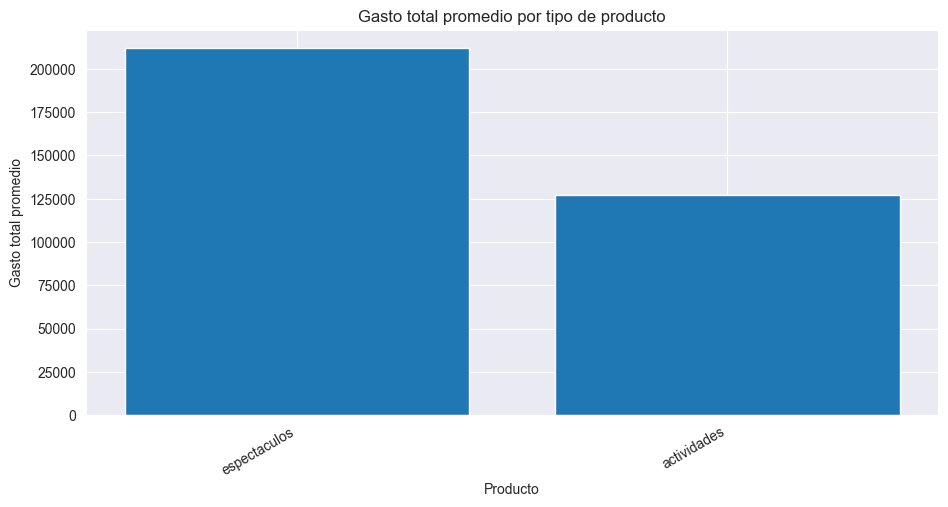

In [90]:
plt.figure()
plt.bar(prod["producto"], prod["gasto_total_promedio"])
plt.xlabel("Producto")
plt.ylabel("Gasto total promedio")
plt.title("Gasto total promedio por tipo de producto")
plt.xticks(rotation=30, ha="right")
# Guardar en assets

plt.savefig(ASSETS_DIR / "Gasto total promedio por tipo de producto.png", dpi=300)
plt.show()
plt.close()

Espectáculos presentan un gasto total promedio cercano a 212.000.
Actividades presentan un gasto total promedio cercano a 127.000.
La diferencia absoluta supera las 80.000 unidades monetarias, lo que representa aproximadamente un 65–67% más de gasto promedio en espectáculos respecto a actividades.
Los espectáculos constituyen el segmento con mayor impacto económico agregado dentro del dataset. Esto sugiere que:
Generan mayor volumen de consumo.
Poseen mayor capacidad de atracción.
Funcionan como eventos tractores de gasto turístico.
A pesar de que anteriormente se observó que el precio medio de entrada en actividades es mayor, el volumen agregado de los espectáculos compensa ampliamente su menor precio unitario.
Esto sugiere que:
Espectáculos operan bajo un modelo masivo.
Actividades operan bajo un modelo más segmentado o especializado.
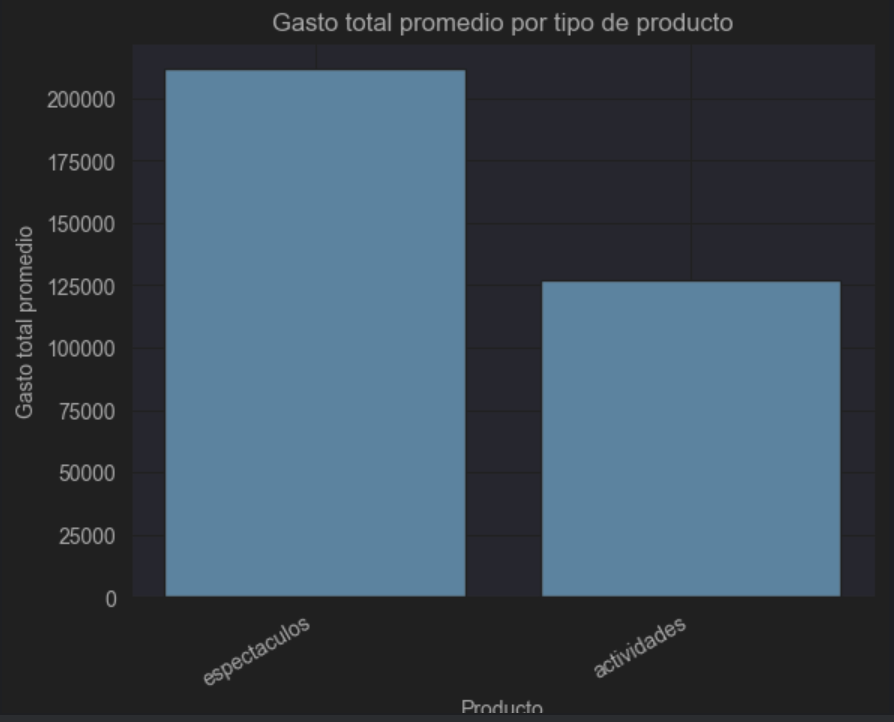

El análisis confirma que el comportamiento del gasto no está determinado únicamente por el precio medio de entrada, sino por la combinación entre:
Precio
Frecuencia de consumo
Volumen de registros
Capacidad de atracción territorial
Esto refuerza la importancia de incorporar ambas variables (precio y gasto) en modelos predictivos o de planificación turística.

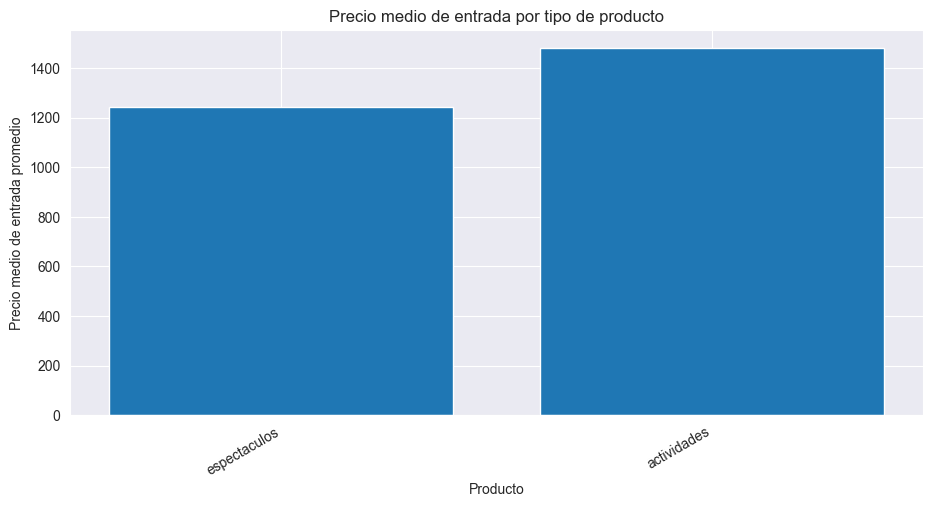

In [91]:
plt.figure()
plt.bar(prod["producto"], prod["precio_medio_entrada_promedio"])
plt.xlabel("Producto")
plt.ylabel("Precio medio de entrada promedio")
plt.title("Precio medio de entrada por tipo de producto")
plt.xticks(rotation=30, ha="right")
# Guardar en assets

plt.savefig(ASSETS_DIR / "Precio medio de entrada por tipo de producto.png", dpi=300)
plt.show()
plt.close()

Actividades → Precio medio ≈ 1.480
Espectáculos → Precio medio ≈ 1.240
Esto implica que:
Las actividades son aproximadamente 19–20% más caras en promedio que los espectáculos.
El mayor precio medio en actividades indica:
Posible carácter más especializado.
Experiencias más personalizadas o limitadas en capacidad.
Segmentación hacia un público con mayor disposición a pagar.
Podrían incluir:
Experiencias guiadas
Actividades temáticas
Turismo experiencial
Talleres o visitas exclusivas
Aunque los espectáculos presentan menor precio medio, ya vimos que generan mayor gasto total.
Esto confirma un modelo basado en:
Alta asistencia
Eventos masivos
Economías de escala
Mayor frecuencia de consumo
El gasto agregado no depende únicamente del precio unitario, sino del volumen de consumo.

Este hallazgo permite definir dos líneas estratégicas diferenciadas:
Estrategia 1 – Maximización de impacto económico territorial
Priorizar espectáculos.
Estrategia 2 – Maximización de ingreso medio por usuario
Priorizar actividades.
Estrategia óptima
Diseñar itinerarios híbridos que combinen:
Eventos masivos (para dinamizar gasto agregado)
Experiencias premium (para elevar ticket medio)

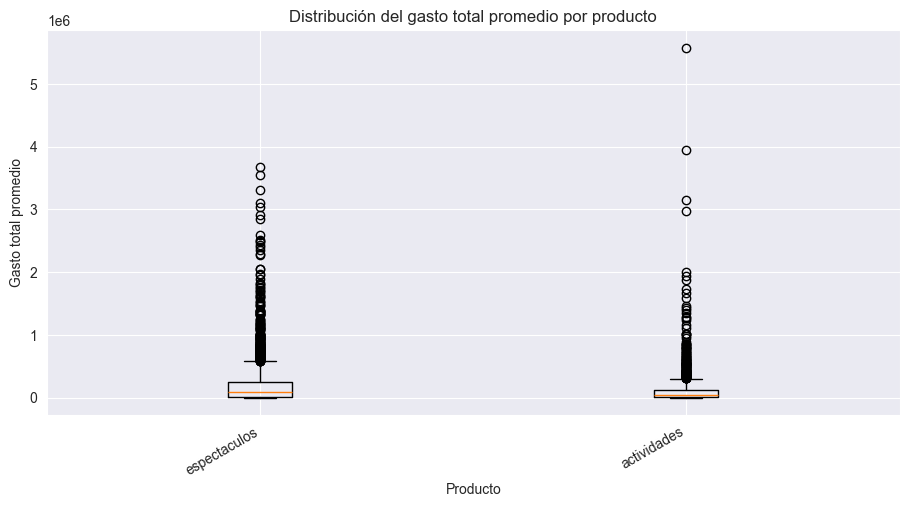

In [92]:
# Distribución (boxplot) para observar dispersión y outliers
plt.figure()
plt.boxplot(
    [df_actividades.loc[df_actividades["producto"]==p,"gasto_total_promedio"].dropna().values for p in prod["producto"]],
    tick_labels=prod["producto"]
)
plt.xlabel("Producto")
plt.ylabel("Gasto total promedio")
plt.title("Distribución del gasto total promedio por producto")
plt.xticks(rotation=30, ha="right")
# Guardar en assets

plt.savefig(ASSETS_DIR / "Distribucion del gasto total promedio por producto.png", dpi=300)
plt.show()
plt.close()

Espectáculos
Actividades
Se observan tres elementos clave:
Alta dispersión en ambos productos
Fuerte asimetría positiva
Presencia significativa de outliers extremos
Espectáculos
Actividades
Se observan tres elementos clave:
Alta dispersión en ambos productos
Fuerte asimetría positiva
Presencia significativa de outliers extremos
Aunque el promedio general favorece a espectáculos, el gráfico muestra que:
Actividades presenta outliers más extremos (superiores a 5 millones).
La dispersión relativa parece mayor.
Esto sugiere que:
Algunas actividades generan picos económicos muy elevados.
El comportamiento es menos estable.
Puede haber provincias con turismo experiencial altamente concentrado.
Dado que hay fuerte presencia de outliers:
El promedio puede estar inflado.
La mediana probablemente sería:
Más representativa del comportamiento típico.
Menos sensible a eventos excepcionales.

## Categorías y subcategorías
Se analiza la composición de `categoria` y `subcategoria`, y su relación con gasto y precio para identificar patrones de consumo por tipo de actividad.

In [39]:
top_cat = df_actividades["categoria"].value_counts().reset_index()
top_cat.columns = ["categoria","registros"]
top_cat

,categoria,registros
0,vida nocturna,1179
1,paisaje naturaleza,859
2,paisaje urbano,707
3,servicios,295
4,comida y bebida,266
5,otros,203
6,compras,100


Las tres primeras categorías representan aproximadamente:
 77% del total de registros
Esto indica una fuerte concentración en:
Vida nocturna
Turismo de naturaleza
Turismo urbano
Esto sugiere que el modelo está capturando principalmente:
Experiencias sociales
Experiencias territoriales
Experiencias de ocio urbano
Con más del 30% del total, vida nocturna es la categoría más representada.
Posibles interpretaciones:
Alta frecuencia de eventos.
Fuerte actividad económica asociada.
Relevancia en destinos urbanos.
Importancia en turismo joven o experiencial.
Esto puede explicar parte de los picos observados en gasto.
Paisaje naturaleza (24%) + paisaje urbano (20%) suman casi 45%.
Esto revela que:
El componente territorial y experiencial es central en el dataset.
No es solo ocio nocturno — existe fuerte peso en turismo paisajístico.
Compras (3%)
Otros (6%)
Comida y bebida (7%)
Esto podría indicar:
Subrepresentación en la fuente.
Menor disponibilidad de datos.
Diferente modelo de clasificación en DataEstur.
Esto es importante porque puede generar sesgo en el análisis económico.
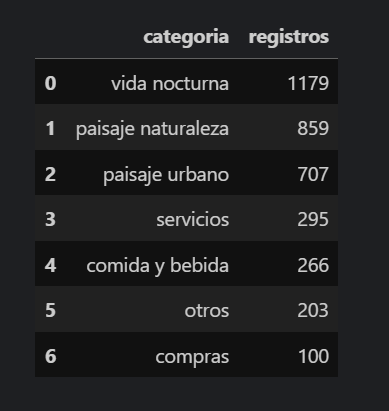

In [40]:
cat_stats = df_actividades.groupby("categoria", as_index=False).agg(
    gasto_promedio=("gasto_total_promedio","mean"),
    precio_promedio=("precio_medio_entrada_promedio","mean"),
    registros=("id_actividad","count")
).sort_values("gasto_promedio", ascending=False)

cat_stats.head(15)

,categoria,gasto_promedio,precio_promedio,registros
6,vida nocturna,242129.068677,979.152299,1179
4,paisaje urbano,199138.461782,948.464866,707
3,paisaje naturaleza,147070.114552,1260.765506,859
2,otros,133077.322906,2584.308325,203
5,servicios,111329.295864,2487.706949,295
1,compras,108047.773300,3699.891600,100
0,comida y bebida,82993.477895,1063.748459,266


Vida nocturna — Motor económico principal
Gasto promedio: 242.129 (el más alto)
Precio promedio: 979 (de los más bajos)
Registros: 1.179 (la categoría con mayor volumen)
Interpretación:
Vida nocturna domina en las tres dimensiones clave:
Mayor gasto agregado
Mayor número de registros
Precio relativamente bajo
Paisaje urbano — Segundo eje económico
Gasto promedio: 199.138
Precio promedio: 948
Registros: 707
Modelo muy similar a vida nocturna:
Precio bajo–medio
Volumen considerable
Alto impacto agregado
Paisaje naturaleza — Modelo híbrido
Gasto promedio: 147.070
Precio promedio: 1.260
Registros: 859
Aquí cambia la dinámica:
Precio más alto
Volumen medio
Gasto agregado menor que urbano
Compras — Ticket más alto, impacto limitado
Precio promedio: 3.699 (el más alto)
Gasto promedio: 108.047
Registros: 100 (muy bajo volumen)
Esto es muy interesante:
Alto precio unitario
Bajo volumen
Impacto agregado moderado
Servicios y Otros — Segmento intermedio
Precios elevados (≈2.400–2.500)
Volumen bajo–medio
Gasto agregado medio
Podrían representar consumo complementario.
Comida y bebida — Bajo impacto agregado
Precio medio ≈ 1.063
Gasto promedio más bajo del grupo
Volumen moderado
Podría indicar:
Alta dispersión
Consumo fragmentado
Menor concentración económica

El modelo cultural español (según el dataset) presenta tres dinámicas claras:
🟢 Modelo 1 — Volumen masivo (vida nocturna, paisaje urbano)
Precio bajo + alto volumen = mayor impacto agregado
🟡 Modelo 2 — Experiencial (naturaleza)
Precio medio-alto + volumen medio
🔴 Modelo 3 — Premium fragmentado (compras, servicios)
Precio alto + bajo volumen

## Análisis territorial (CCAA y provincias)
Gracias al enriquecimiento del ETL, se incorporan `id_ccaa` e `id_provincia`, permitiendo análisis consistentes por jerarquía territorial.

In [41]:
ccaa_stats = df_actividades.groupby(["id_ccaa","comunidad_autonoma"], as_index=False).agg(
    gasto_promedio=("gasto_total_promedio","mean"),
    precio_promedio=("precio_medio_entrada_promedio","mean"),
    registros=("id_actividad","count")
).sort_values("gasto_promedio", ascending=False)

ccaa_stats.head(20)

,id_ccaa,comunidad_autonoma,gasto_promedio,precio_promedio,registros
6,15,comunidad foral de navarra,500926.222951,1984.731475,61
4,13,comunidad de madrid,500868.501587,2164.897540,126
10,2,aragon,254419.836308,1194.717641,195
1,10,comunitat valenciana,234517.145421,1833.991722,273
7,16,pais vasco,199337.430233,1401.105875,257
0,1,andalucia,186488.067039,1174.503625,618
12,4,illes balears,178858.345194,1423.206357,129
5,14,region de murcia,173266.386279,1467.951977,86
8,17,la rioja,161449.759464,1600.060179,56
15,7,castilla y leon,157919.952109,1119.311290,403


El cuadro muestra diferencias muy significativas entre comunidades en tres dimensiones:
Gasto promedio
Precio promedio
Número de registros
1) Comunidades con mayor gasto promedio
Las dos primeras posiciones:
Navarra → ~500.926
Madrid → ~500.868
Ambas prácticamente duplican el promedio nacional.
Interpretación:
Estas comunidades presentan:
✔ Alta intensidad económica cultural
✔ Posible concentración de eventos estratégicos
✔ Mayor capacidad de consumo
En el caso de Madrid, puede explicarse por:
Capitalidad
Concentración de espectáculos y vida nocturna
Turismo internacional
Navarra es especialmente interesante porque:
Tiene solo 61 registros
Pero un gasto promedio extremadamente alto
Esto sugiere posible concentración en eventos muy específicos o picos puntuales.
2) Bloque intermedio-alto
Aragón
Comunitat Valenciana
País Vasco
Andalucía
Estas comunidades muestran:
Gasto sólido
Volumen considerable
Precio medio relativamente estable
Andalucía destaca por:
✔ Mayor número de registros (618)
✔ Gasto alto pero no extremo
3) Bloque medio
Cataluña
Castilla y León
Illes Balears
Murcia
La Rioja
Presentan equilibrio entre precio y volumen.
4) Bloque de menor gasto promedio
Galicia
Extremadura
Ceuta
Especialmente:
Ceuta → bajo volumen (23 registros)
Extremadura → precio más bajo (~744)
Menor intensidad económica cultural.
Esto puede reflejar:
Menor densidad de eventos
Menor concentración turística
Estructura económica distinta
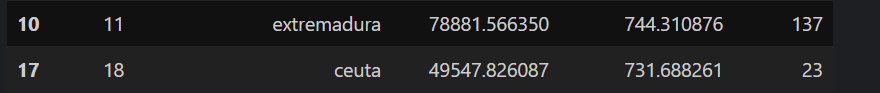

1) Madrid y Navarra son outliers territoriales
Especialmente Navarra, porque combina:
Alto gasto
Bajo número de registros
Esto puede indicar:
Eventos premium
Concentración en pocas actividades de alto valor
2) Andalucía y Cataluña → Modelo de volumen
Tienen muchos registros pero gasto promedio moderado.
Modelo masivo, menos concentrado.
3) Asturias presenta precio muy alto (~2269)
Pero gasto promedio relativamente bajo (~90.000).
Esto confirma nuevamente:
Precio alto no garantiza impacto agregado alto.

In [42]:
prov_stats = df_actividades.groupby(["id_provincia","provincia"], as_index=False).agg(
    gasto_promedio=("gasto_total_promedio","mean"),
    precio_promedio=("precio_medio_entrada_promedio","mean"),
    registros=("id_actividad","count")
).sort_values("gasto_promedio", ascending=False)

prov_stats.head(20)

,id_provincia,provincia,gasto_promedio,precio_promedio,registros
24,31,navarra,500926.222951,1984.731475,61
20,28,madrid,500868.501587,2164.897540,126
40,46,valencia/valencia,390738.907328,2534.283103,116
45,50,zaragoza,341603.756491,1326.846579,114
42,48,bizkaia,289930.079703,2009.499010,101
49,8,barcelona,281041.748992,1805.154884,129
35,41,sevilla,236390.959138,1013.735948,116
21,29,malaga,235545.739159,1472.946822,107
5,14,cordoba,226573.944643,920.363929,56
41,47,valladolid,225791.842990,1215.748866,97


1) Provincias con mayor gasto promedio
Top absoluto:
Navarra → ~500.926
Madrid → ~500.868
Ambas prácticamente duplican a la mayoría de provincias.
Interpretación:
Estas provincias funcionan como:
✔ Polos culturales de alto impacto
✔ Centros de eventos estratégicos
✔ Hubs de consumo cultural intensivo
En el caso de Madrid, es consistente con su papel como capital nacional.
Navarra, en cambio, es especialmente interesante por su menor número de registros (61), lo que sugiere concentración en eventos muy específicos y de alto valor.
2) Segundo bloque de alto dinamismo
Valencia/Valencia → ~390.738
Zaragoza → ~341.603
Bizkaia → ~289.930
Barcelona → ~281.041
Aquí vemos grandes capitales o provincias con fuerte dinamismo urbano.
Patrón común:
✔ Precio medio relativamente alto
✔ Volumen moderado
✔ Alto impacto agregado
Esto refuerza el modelo urbano-cultural.
3) Modelo andaluz de volumen
Sevilla
Málaga
Córdoba
Almería
Estas provincias muestran:
✔ Gasto alto pero no extremo
✔ Precio medio más bajo
✔ Volumen considerable
Modelo basado en oferta amplia y consumo distribuido.
4) Provincias con precio alto pero gasto moderado
Ejemplos interesantes:
Valencia → precio ≈ 2.534
Bizkaia → precio ≈ 2.009
Pero su gasto no alcanza el nivel de Navarra o Madrid.
Esto confirma nuevamente:
Precio elevado no garantiza mayor impacto agregado.
5) Provincias con menor impacto relativo
Palencia
Huelva
Zamora
Presentan:
✔ Menor volumen
✔ Menor gasto
✔ Precios intermedios
Indica menor intensidad cultural o menor concentración de eventos.

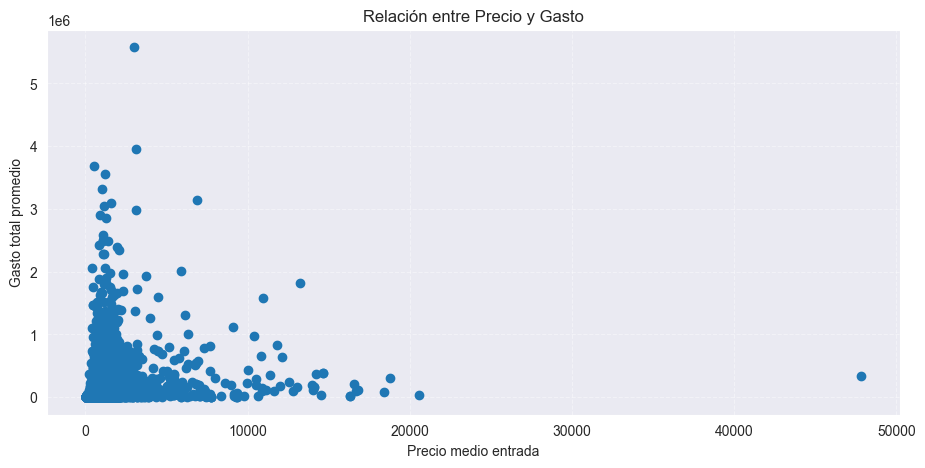

In [93]:
plt.figure()

plt.scatter(
    df_actividades["precio_medio_entrada_promedio"],
    df_actividades["gasto_total_promedio"]
)

plt.xlabel("Precio medio entrada")
plt.ylabel("Gasto total promedio")
plt.title("Relación entre Precio y Gasto")

plt.grid(True, linestyle="--", alpha=0.4)
# Guardar en assets

plt.savefig(ASSETS_DIR / "Relacion entre Precio y Gasto.png", dpi=300)
plt.show()
plt.close()

No existe correlación lineal positiva clara
Si el precio fuera el principal determinante del gasto, esperaríamos:
A mayor precio → mayor gasto
Pero el gráfico muestra lo contrario:
Muchos puntos con precios bajos generan gastos muy altos.
Algunos precios extremadamente altos no generan alto gasto.
Esto indica que:
El gasto no depende directamente del precio unitario.
La distribución tiene forma de embudo:
En precios bajos hay gran variabilidad de gasto.
En precios altos el gasto tiende a concentrarse en niveles medios o bajos.
Esto sugiere que:
✔ El volumen domina el comportamiento económico.
✔ Los eventos masivos (precio bajo) pueden generar grandes ingresos agregados.
✔ Los productos premium (precio alto) tienen menor penetración.
Outliers significativos
Se observan:
Valores de gasto superiores a 5 millones con precios relativamente bajos.
Un punto extremo en precio cercano a 50.000 que no genera gasto proporcional.
Esto refuerza:
La existencia de eventos tractores.
La no proporcionalidad entre precio y gasto.

El modelo cultural observado sigue un patrón:
Modelo masivo > Modelo premium
Es decir:
Productos de bajo precio pero alta asistencia generan mayor impacto económico.
Productos caros no escalan en gasto agregado.
Este hallazgo es clave para planificación estratégica.

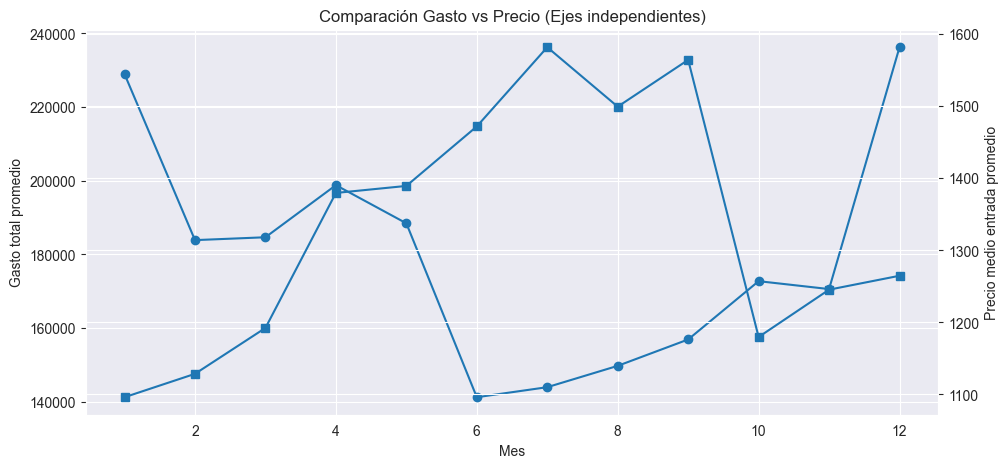

In [94]:
fig, ax1 = plt.subplots()

df_mes = df_actividades.groupby("mes", as_index=False).agg(
    gasto_promedio=("gasto_total_promedio", "mean"),
    precio_promedio=("precio_medio_entrada_promedio", "mean")
).sort_values("mes")

# Primer eje (gasto)
ax1.plot(df_mes["mes"], df_mes["gasto_promedio"], marker="o")
ax1.set_xlabel("Mes")
ax1.set_ylabel("Gasto total promedio")

# Segundo eje (precio)
ax2 = ax1.twinx()
ax2.plot(df_mes["mes"], df_mes["precio_promedio"], marker="s")
ax2.set_ylabel("Precio medio entrada promedio")

plt.title("Comparación Gasto vs Precio (Ejes independientes)")
# Guardar en assets

plt.savefig(ASSETS_DIR / "Comparacion Gasto vs Precio.png", dpi=300)
plt.show()
plt.close()

El gráfico muestra:
Línea 1 → Gasto total promedio (eje izquierdo)
Línea 2 → Precio medio de entrada (eje derecho)
Esto permite analizar si ambas variables se mueven de forma conjunta o independiente.
No existe relación proporcional directa mes a mes
Observaciones claras:
Mes 6 (junio) → Precio alto pero gasto bajo.
Mes 1 y 12 → Gasto muy alto con precio moderado.
Mes 7–9 → Precio elevado pero gasto medio.
Esto confirma nuevamente que:
El gasto no está determinado únicamente por el precio.
El gasto muestra:
Pico en enero.
Caída fuerte en junio.
Recuperación progresiva en otoño.
Máximo en diciembre.
Esto sugiere:
✔ Efecto fin de año
✔ Eventos festivos
✔ Temporada cultural alta
Precio sigue patrón diferente
El precio:
Aumenta progresivamente hasta julio.
Se mantiene alto en verano.
Cae en octubre.
Se estabiliza a fin de año.
Esto sugiere:
✔ Temporada alta de verano → precios altos
✔ Temporada navideña → gasto alto, no necesariamente precio alto

## Valoraciones: cobertura e impacto
Se compara gasto/precio entre observaciones con y sin valoraciones, y se describen rangos de valoración cuando están disponibles.


In [45]:
cov = df_actividades["hay_valoracion"].value_counts().rename_axis("hay_valoracion").reset_index(name="registros")
cov["porcentaje"] = (cov["registros"]/cov["registros"].sum()*100).round(2)
cov

,hay_valoracion,registros,porcentaje
0,True,3567,98.84
1,False,42,1.16


Resultados:
Con valoración (True): 3.567 registros → 98,84%
Sin valoración (False): 42 registros → 1,16%
Total: 3.609 registros
El 1,16% de registros sin valoración:
Es marginal.
No genera sesgo estructural.
No afecta significativamente medias o correlaciones.
Puedes justificar:
No es necesario imputar.
Se pueden excluir sin afectar resultados.
Dado que casi todo el dataset tiene valoración:
✔ Se puede analizar relación entre reputación y gasto.
✔ Se puede modelar impacto de calidad percibida.
✔ Se puede estudiar elasticidad reputación–precio.

In [46]:
impact = df_actividades.groupby("hay_valoracion", as_index=False).agg(
    gasto_promedio=("gasto_total_promedio","mean"),
    precio_promedio=("precio_medio_entrada_promedio","mean"),
    registros=("id_actividad","count")
)
impact

,hay_valoracion,gasto_promedio,precio_promedio,registros
0,False,50326.107143,942.936429,42
1,True,180324.776459,1340.009490,3567


El gasto promedio con valoración es:
Más de 3,5 veces superior al de registros sin valoración.
Los registros con valoración presentan:
✔ Precio medio mayor
✔ Gasto agregado mayor
Esto sugiere que:
Las experiencias mejor posicionadas digitalmente tienden a ser más dinámicas económicamente.
La visibilidad y reputación pueden estar asociadas a mayor demanda.
Las actividades sin valoración pueden ser:
Nuevas
Poco promocionadas
De menor escala
Menos digitalizadas
Mientras que las actividades con valoración:
Tienen mayor tracción
Mayor interacción de usuarios
Mayor volumen de consumo

In [47]:
# Distribución de valoraciones (solo donde hay)
vals = df_actividades[df_actividades["hay_valoracion"]==True][["valoracion_general_promedio","total_opiniones_categoria_promedio"]].describe().T
vals

,count,mean,std,min,25%,50%,75%,max
valoracion_general_promedio,3567.0,4.239313,0.100118,3.97,4.17,4.25,4.31,4.43
total_opiniones_categoria_promedio,3567.0,36710.406224,80925.862790,2.00,1298.00,6934.00,39053.00,732080.00


Análisis de la valoración general promedio
Valoración extremadamente alta y estable
El rango es muy estrecho:
Entre 3.97 y 4.43
Desviación estándar muy baja (0.10)
Esto indica:
✔ Alta homogeneidad
✔ Alta satisfacción general
✔ Baja dispersión
Valoración extremadamente alta y estable
El rango es muy estrecho:
Entre 3.97 y 4.43
Desviación estándar muy baja (0.10)
Esto indica:
✔ Alta homogeneidad
✔ Alta satisfacción general
✔ Baja dispersión
Análisis del total de opiniones por categoría
Alta asimetría positiva
Aquí sí hay fuerte dispersión:
Media (36.710) es mucho mayor que mediana (6.933)
Esto indica que:
✔ Existen casos extremadamente populares.
✔ Hay concentración en pocas actividades.
✔ Distribución tipo Pareto.
Presencia de outliers masivos
Un máximo de 732.080 opiniones es muy alto.
Esto sugiere:
Algunas actividades dominan la conversación digital.
Existen polos de alta visibilidad online.

## Detección rápida de valores extremos
Se identifican percentiles altos para gasto y precio, con el fin de reconocer outliers que puedan sesgar promedios.

In [48]:
for c in ["gasto_total_promedio","precio_medio_entrada_promedio"]:
    p95 = df_actividades[c].quantile(0.95)
    p99 = df_actividades[c].quantile(0.99)
    print(c, "p95:", round(p95,2), "p99:", round(p99,2))

gasto_total_promedio p95: 729580.76 p99: 1681179.38
precio_medio_entrada_promedio p95: 3652.0 p99: 9931.64


Análisis de percentiles 95 y 99
Gasto total promedio
P95: 729.580
P99: 1.681.179
Esto significa que:
El 95% de los registros tiene gasto ≤ 729k
Solo el 1% supera 1,68 millones
Análisis de percentiles 95 y 99
Gasto total promedio
P95: 729.580
P99: 1.681.179
Esto significa que:
El 95% de los registros tiene gasto ≤ 729k
Solo el 1% supera 1,68 millones
Confirmación de asimetría fuerte
Ya sabíamos que había outliers.
Ahora lo cuantificamos:
El salto de P95 a P99 es enorme.
En gasto:
P95 → 729k
P99 → 1,68M
Más del doble.
Eso indica eventos o provincias extremadamente dominantes.
Estructura tipo Pareto
Esto sugiere que:
✔ Una pequeña fracción genera una gran proporción del gasto.
✔ El sistema cultural tiene concentración económica.
✔ Existen “super eventos” o polos culturales.

In [49]:
# Top 10 por gasto (posibles outliers)
df_actividades.sort_values("gasto_total_promedio", ascending=False).head(10)[
    ["id_actividad","mes","producto","categoria","subcategoria","comunidad_autonoma","provincia","gasto_total_promedio","precio_medio_entrada_promedio"]
]


,id_actividad,mes,producto,categoria,subcategoria,comunidad_autonoma,provincia,gasto_total_promedio,precio_medio_entrada_promedio
3403,3404,12,actividades,paisaje naturaleza,deportes y aventuras,pais vasco,gipuzkoa,5578091.00,3000.00
24,25,1,actividades,paisaje naturaleza,actividades infantiles,comunidad foral de navarra,navarra,3953396.00,3143.50
1937,1938,7,espectaculos,vida nocturna,musica,castilla y leon,salamanca,3678171.00,546.40
222,223,1,espectaculos,vida nocturna,musica,comunidad de madrid,madrid,3553172.24,1235.79
2883,2884,10,espectaculos,vida nocturna,musica,aragon,zaragoza,3311083.60,1024.40
2032,2033,8,actividades,paisaje naturaleza,actividades infantiles,pais vasco,bizkaia,3148063.00,6911.38
3245,3246,11,espectaculos,vida nocturna,musica,comunidad de madrid,madrid,3100594.85,1561.18
1348,1349,5,espectaculos,vida nocturna,musica,comunidad de madrid,madrid,3043775.34,1137.34
80,81,1,actividades,paisaje naturaleza,deportes y aventuras,pais vasco,gipuzkoa,2976506.00,3107.00
2171,2172,8,espectaculos,paisaje urbano,"cultura, teatro y danza",castilla y leon,valladolid,2908236.00,915.62


Análisis del Top gasto total promedio
Se observan registros con valores superiores a 3 millones e incluso uno superior a 5,5 millones.
Caso máximo absoluto
Gipuzkoa (País Vasco)
Categoría: Paisaje naturaleza
Subcategoría: Deportes y aventuras
Mes: 12
Gasto: 5.578.091
Precio: 3.000
Esto es un outlier extremo.
Interpretación:
Puede tratarse de un evento puntual de gran escala o concentración estacional.
Concentración en vida nocturna (música)
Muchos de los registros top corresponden a:
Categoría: Vida nocturna
Subcategoría: Música
Provincias: Madrid, Salamanca, Zaragoza
Esto confirma:
✔ Los espectáculos musicales son grandes generadores de gasto.
✔ Las capitales y ciudades universitarias tienen fuerte dinamismo cultural.
✔ Eventos musicales tienen efecto tractor.
Concentración en vida nocturna (música)
Muchos de los registros top corresponden a:
Categoría: Vida nocturna
Subcategoría: Música
Provincias: Madrid, Salamanca, Zaragoza
Esto confirma:
✔ Los espectáculos musicales son grandes generadores de gasto.
✔ Las capitales y ciudades universitarias tienen fuerte dinamismo cultural.
✔ Eventos musicales tienen efecto tractor.
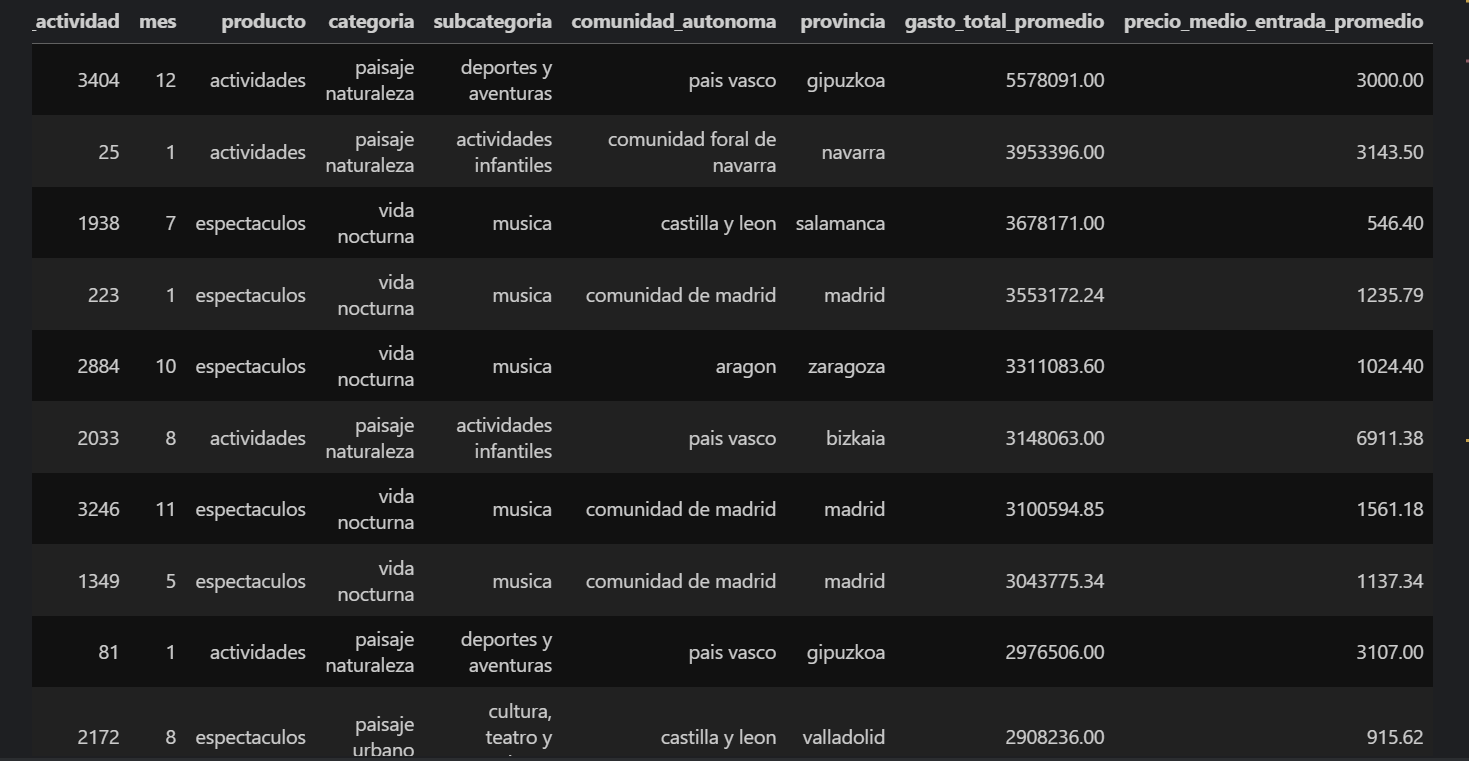

In [50]:
# -----------------------------
# 1.2) Limpieza ligera de strings
# -----------------------------
for c in ["categoria","producto","subcategoria","comunidad_autonoma","provincia"]:
    if c in df_actividades.columns:
        df_actividades[c] = (df_actividades[c].astype(str).str.strip()
                         .str.lower()
                         .str.replace(r"\s+", " ", regex=True))

# Distribución y rango de costes (base para estimación)

In [51]:
# -----------------------------
# 2) Distribución de variables económicas
# -----------------------------
cols_coste = ["gasto_total_promedio","precio_medio_entrada_promedio"]

df_actividades[cols_coste].describe().T

,count,mean,std,min,25%,50%,75%,max
gasto_total_promedio,3609.0,178811.907490,341642.448160,49.0,13024.00,63827.0,196873.90,5578091.0
precio_medio_entrada_promedio,3609.0,1335.388523,1890.121841,25.0,531.69,952.0,1453.71,47799.0


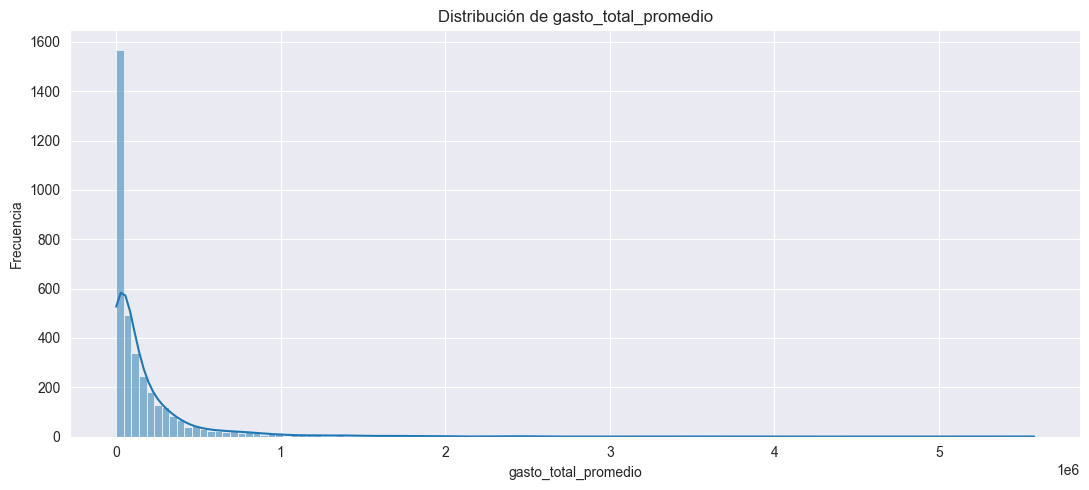

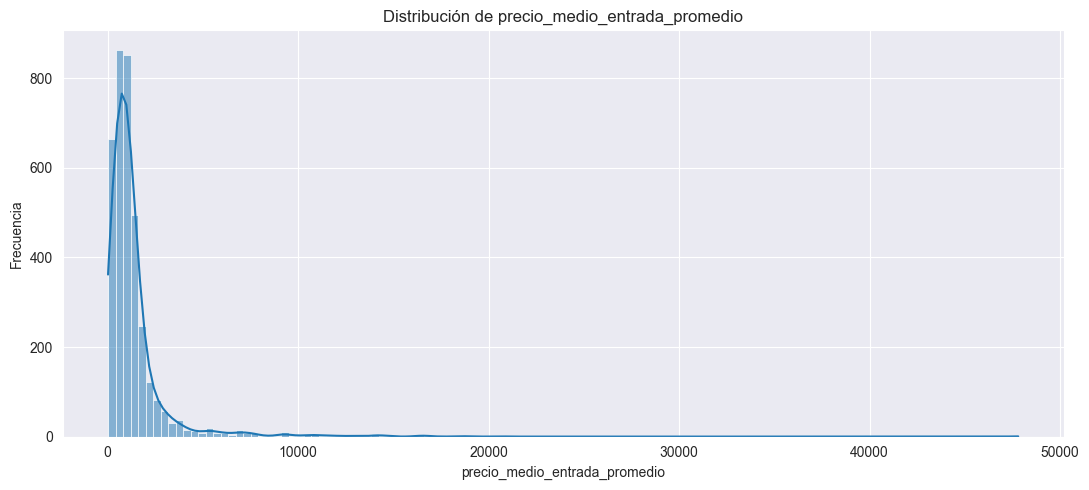

In [95]:
# Histogramas + KDE
for col in cols_coste:
    plt.figure()
    sns.histplot(df_actividades[col].dropna(), kde=True)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
   # Guardar en assets

plt.savefig(ASSETS_DIR / "Distribucion de gasto total promedio y precio medio promedio.png", dpi=300)
plt.show()
plt.close()

Gasto total promedio : La distribución está fuertemente sesgada a la derecha.
Un pequeño número de combinaciones (mes–provincia–actividad) concentra volúmenes de gasto extremadamente altos, mientras que la mayoría tiene gastos mucho más moderados.
También hay asimetría fuerte, pero menos extrema que el gasto total.
La mayoría de actividades se mueve entre 500 y 1,500, pero existen actividades premium o agregadas con precios muy altos
El análisis descriptivo evidencia una fuerte heterogeneidad en los costes de las actividades turísticas, lo que justifica el uso de métricas robustas (medianas y percentiles) para la estimación de presupuestos. Esta aproximación permite al sistema CulturaTrip generar recomendaciones realistas y adaptadas al perfil económico del viajero, evitando sesgos derivados de valores extremos
Dada la fuerte asimetría observada en las variables económicas, se descartó el uso de la media como estimador principal de coste, priorizando métricas robustas como la mediana y los percentiles, con el fin de evitar sesgos derivados de valores extremos.

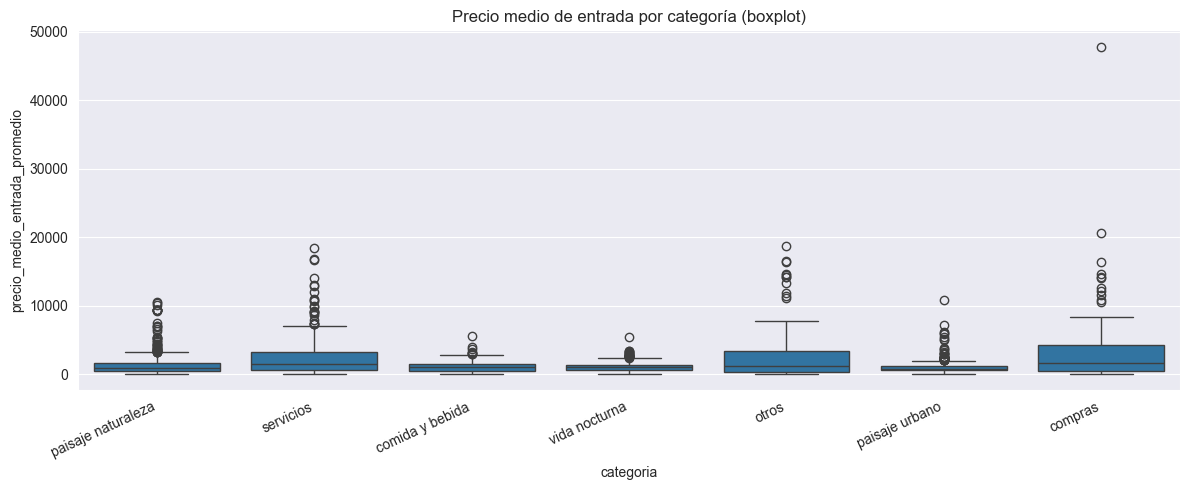

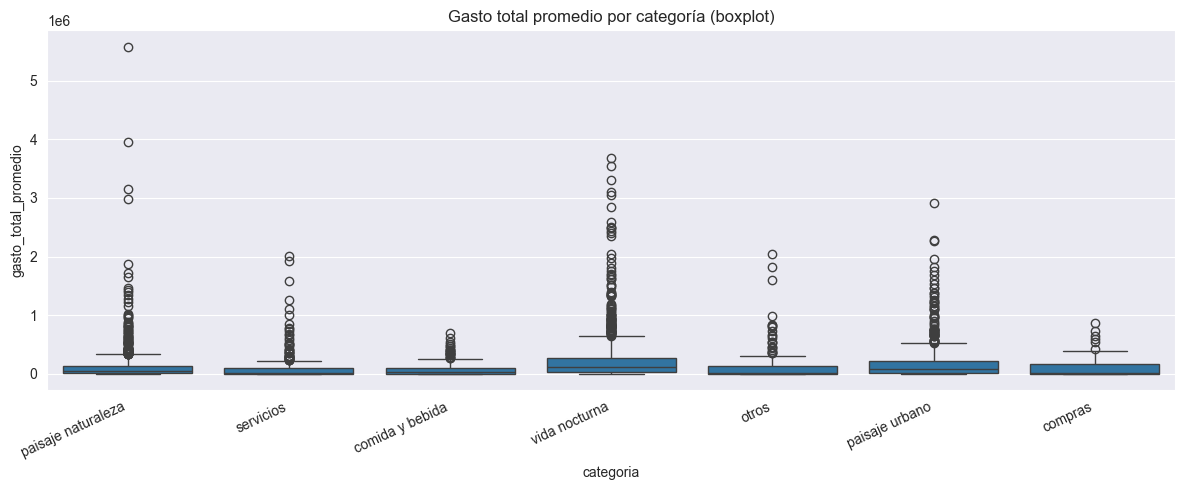

In [96]:
# Boxplot por categoría (coste)
plt.figure(figsize=(12,5))
sns.boxplot(data=df_actividades, x="categoria", y="precio_medio_entrada_promedio")
plt.title("Precio medio de entrada por categoría (boxplot)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
sns.boxplot(data=df_actividades, x="categoria", y="gasto_total_promedio")
plt.title("Gasto total promedio por categoría (boxplot)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
# Guardar en assets

plt.savefig(ASSETS_DIR / "Precio y Gasto medio por categoria.png", dpi=300)
plt.show()
plt.close()

El precio medio depende fuertemente de la categoría, y algunas presentan una variabilidad extrema que invalida el uso de la media como métrica representativa.
El análisis por categoría revela una fuerte heterogeneidad en los precios, especialmente en las categorías de compras y servicios, lo que justifica la aplicación de estimadores robustos y reglas de segmentación específicas por tipo de actividad.
Precio alto no implica necesariamente mayor impacto económico agregado.
Las categorías con mayor gasto total no coinciden necesariamente con las de mayor precio medio, evidenciando que el impacto económico turístico está más relacionado con el volumen de participación que con el coste individual de las actividades.

## Ranking territorial (CCAA y provincias)

In [54]:
print(df_muni.columns)
print(df_geo.columns)
print(df_ccaa.columns)

Index(['id_pais', 'id_municipio', 'id_municipio_parcial', 'id_provincia',
       'id_ccaa', 'nombre', 'provincia_nombre', 'ccaa_nombre', 'id_isla',
       'isla', 'gid_municipio', 'gid_provincia', 'gid_ccaa'],
      dtype='object')
Index(['id_municipio', 'lat', 'lon', 'osm_id', 'osm_type', 'osm_query_usada',
       'osm_pass'],
      dtype='object')
Index(['id_pais', 'id_ccaa', 'ccaa_nombre', 'gid_ccaa'], dtype='object')


In [55]:
df_muni["id_municipio"].nunique()
df_geo["id_municipio"].nunique()

8132

In [56]:
# Merge de Dataset Municipio y GEO
df_muni_geo = df_muni.merge(
    df_geo,
    on="id_municipio",
    how="left",
    validate="1:1"
)

In [57]:
centroides = (
    df_muni_geo
    .groupby(["id_provincia", "provincia_nombre"])[["lat", "lon"]]
    .mean()
    .reset_index()
)

In [58]:
centroides["id_provincia"] = centroides["id_provincia"].astype(str)

In [59]:
print(df_muni_geo.columns)
print(df_actividades. columns)
print(df_ccaa.columns)

Index(['id_pais', 'id_municipio', 'id_municipio_parcial', 'id_provincia',
       'id_ccaa', 'nombre', 'provincia_nombre', 'ccaa_nombre', 'id_isla',
       'isla', 'gid_municipio', 'gid_provincia', 'gid_ccaa', 'lat', 'lon',
       'osm_id', 'osm_type', 'osm_query_usada', 'osm_pass'],
      dtype='object')
Index(['id_actividad', 'id_pais', 'id_ccaa', 'id_provincia', 'mes',
       'categoria', 'producto', 'subcategoria', 'comunidad_autonoma',
       'provincia', 'gasto_total_promedio', 'precio_medio_entrada_promedio',
       'valoracion_por_categoria_promedio', 'valoracion_general_promedio',
       'total_opiniones_categoria_promedio', 'hay_valoracion'],
      dtype='object')
Index(['id_pais', 'id_ccaa', 'ccaa_nombre', 'gid_ccaa'], dtype='object')


In [60]:
df_ccaa["id_ccaa"].nunique(), len(df_ccaa)

(19, 19)

In [61]:
dim_ccaa_unique = df_ccaa[["id_ccaa", "ccaa_nombre"]].drop_duplicates()

In [62]:
df_actividades_ccaa = df_actividades.merge(dim_ccaa_unique, on="id_ccaa", how="left")

In [63]:
len(df_actividades)

3609

In [64]:
len(df_actividades_ccaa)

3609

In [65]:
df_actividades.groupby("provincia").size()


provincia
a coruna                   80
albacete                   83
alicante/alacant          111
almeria                    78
araba/alava                80
asturias                   81
avila                      30
badajoz                    67
barcelona                 129
bizkaia                   101
burgos                     28
caceres                    70
cadiz                      82
cantabria                  54
castellon/castello         46
ceuta                      23
ciudad real                59
cordoba                    56
cuenca                     43
gipuzkoa                   76
girona                     95
granada                    86
guadalajara                37
huelva                     34
huesca                     53
illes balears             129
jaen                       59
la rioja                   56
las palmas                105
leon                       44
lleida                     54
lugo                       50
madrid                    126


In [66]:
df_actividades_ccaa.groupby("provincia").size()

provincia
a coruna                   80
albacete                   83
alicante/alacant          111
almeria                    78
araba/alava                80
asturias                   81
avila                      30
badajoz                    67
barcelona                 129
bizkaia                   101
burgos                     28
caceres                    70
cadiz                      82
cantabria                  54
castellon/castello         46
ceuta                      23
ciudad real                59
cordoba                    56
cuenca                     43
gipuzkoa                   76
girona                     95
granada                    86
guadalajara                37
huelva                     34
huesca                     53
illes balears             129
jaen                       59
la rioja                   56
las palmas                105
leon                       44
lleida                     54
lugo                       50
madrid                    126


In [67]:
print(df_actividades_ccaa.columns)

Index(['id_actividad', 'id_pais', 'id_ccaa', 'id_provincia', 'mes',
       'categoria', 'producto', 'subcategoria', 'comunidad_autonoma',
       'provincia', 'gasto_total_promedio', 'precio_medio_entrada_promedio',
       'valoracion_por_categoria_promedio', 'valoracion_general_promedio',
       'total_opiniones_categoria_promedio', 'hay_valoracion', 'ccaa_nombre'],
      dtype='object')


In [68]:
# -----------------------------
# 3) Agregaciones por región
# -----------------------------
metricas = {
    "gasto_total_promedio": "sum",           # volumen total
    "precio_medio_entrada_promedio": "mean", # nivel de precio
    "valoracion_por_categoria_promedio": "mean",
    "valoracion_general_promedio": "mean",
    "total_opiniones_categoria_promedio": "sum"
}

In [69]:
agg_com = (df_actividades_ccaa.groupby("comunidad_autonoma", as_index=False)
             .agg(metricas)
             .rename(columns={
                 "gasto_total_promedio": "gasto_total",
                 "precio_medio_entrada_promedio": "precio_medio",
                 "valoracion_por_categoria_promedio": "valoracion_categoria_media",
                 "valoracion_general_promedio": "valoracion_general_media",
                 "total_opiniones_categoria_promedio": "total_opiniones"
             }))

agg_prov = (df_actividades_ccaa.groupby(["comunidad_autonoma","provincia"], as_index=False)
              .agg(metricas)
              .rename(columns={
                 "gasto_total_promedio": "gasto_total",
                 "precio_medio_entrada_promedio": "precio_medio",
                 "valoracion_por_categoria_promedio": "valoracion_categoria_media",
                 "valoracion_general_promedio": "valoracion_general_media",
                 "total_opiniones_categoria_promedio": "total_opiniones"
              }))

display(agg_com.head())
display(agg_prov.head())

,comunidad_autonoma,gasto_total,precio_medio,valoracion_categoria_media,valoracion_general_media,total_opiniones
0,andalucia,1.152496e+08,1174.503625,4.279806,4.312071,21398743
1,aragon,4.961187e+07,1194.717641,4.126872,4.230923,1417083
2,canarias,2.492946e+07,882.092487,4.153147,4.270660,16548177
3,cantabria,5.713838e+06,1080.807963,4.187222,4.270000,970044
4,castilla - la mancha,3.589609e+07,1444.695575,4.172265,4.177387,1920696


,comunidad_autonoma,provincia,gasto_total,precio_medio,valoracion_categoria_media,valoracion_general_media,total_opiniones
0,andalucia,almeria,16586324.96,1090.640769,4.065000,4.19,824656
1,andalucia,cadiz,10367558.87,1388.662073,4.312683,4.26,405389
2,andalucia,cordoba,12688140.90,920.363929,4.322143,4.29,1227056
3,andalucia,granada,12285569.09,998.191977,4.313953,4.37,3736789
4,andalucia,huelva,5784981.61,1038.263529,4.126471,4.11,228429


In [70]:
# -----------------------------
# 3.1) Función Top-N
# -----------------------------
def top_n(tabla, columna, n=TOP_N, asc=False):
    return (tabla.sort_values(columna, ascending=asc)
                 .head(n)
                 .reset_index(drop=True))

top_com_gasto     = top_n(agg_com,  "gasto_total", TOP_N, asc=False)
top_com_precio    = top_n(agg_com,  "precio_medio", TOP_N, asc=False)
top_com_val       = top_n(agg_com,  "valoracion_general_media", TOP_N, asc=False)
top_com_opin      = top_n(agg_com,  "total_opiniones", TOP_N, asc=False)

top_prov_gasto    = top_n(agg_prov, "gasto_total", TOP_N, asc=False)
top_prov_precio   = top_n(agg_prov, "precio_medio", TOP_N, asc=False)
top_prov_val      = top_n(agg_prov, "valoracion_general_media", TOP_N, asc=False)
top_prov_opin     = top_n(agg_prov, "total_opiniones", TOP_N, asc=False)

print("=== TOP CCAA por gasto ==="); display(top_com_gasto)
print("=== TOP CCAA por precio ==="); display(top_com_precio)
print("=== TOP CCAA por valoración ==="); display(top_com_val)
print("=== TOP CCAA por opiniones ==="); display(top_com_opin)

print("=== TOP Provincias por gasto ==="); display(top_prov_gasto)
print("=== TOP Provincias por precio ==="); display(top_prov_precio)
print("=== TOP Provincias por valoración ==="); display(top_prov_val)
print("=== TOP Provincias por opiniones ==="); display(top_prov_opin)

=== TOP CCAA por gasto ===


,comunidad_autonoma,gasto_total,precio_medio,valoracion_categoria_media,valoracion_general_media,total_opiniones
0,andalucia,1.152496e+08,1174.503625,4.279806,4.312071,21398743
1,comunitat valenciana,6.402318e+07,1833.991722,4.118059,4.165128,12555101
2,castilla y leon,6.364174e+07,1119.311290,4.108883,4.106203,2233137
3,comunidad de madrid,6.310943e+07,2164.897540,4.058571,4.100000,16498699
4,cataluna,5.576925e+07,1419.039437,4.102097,4.169898,35502702
5,pais vasco,5.122972e+07,1401.105875,4.293346,4.336381,3323936
6,aragon,4.961187e+07,1194.717641,4.126872,4.230923,1417083
7,castilla - la mancha,3.589609e+07,1444.695575,4.172265,4.177387,1920696
8,comunidad foral de navarra,3.055650e+07,1984.731475,4.031148,4.230000,406050
9,canarias,2.492946e+07,882.092487,4.153147,4.270660,16548177


=== TOP CCAA por precio ===


,comunidad_autonoma,gasto_total,precio_medio,valoracion_categoria_media,valoracion_general_media,total_opiniones
0,principado de asturias,7301384.12,2269.941481,4.293457,4.350000,1847848
1,comunidad de madrid,63109431.20,2164.897540,4.058571,4.100000,16498699
2,comunidad foral de navarra,30556499.60,1984.731475,4.031148,4.230000,406050
3,comunitat valenciana,64023180.70,1833.991722,4.118059,4.165128,12555101
4,la rioja,9041186.53,1600.060179,4.168036,4.310000,414220
5,region de murcia,14900909.22,1467.951977,3.819070,4.200000,213946
6,castilla - la mancha,35896086.83,1444.695575,4.172265,4.177387,1920696
7,illes balears,23072726.53,1423.206357,4.287054,4.330000,12936974
8,cataluna,55769249.94,1419.039437,4.102097,4.169898,35502702
9,pais vasco,51229719.57,1401.105875,4.293346,4.336381,3323936


=== TOP CCAA por valoración ===


...

,comunidad_autonoma,provincia,gasto_total,precio_medio,valoracion_categoria_media,valoracion_general_media,total_opiniones
0,castilla - la mancha,ciudad real,3754147.51,2801.864237,4.323898,4.29,143578
1,comunitat valenciana,valencia/valencia,45325713.25,2534.283103,4.180862,4.15,5844484
2,principado de asturias,asturias,7301384.12,2269.941481,4.293457,4.35,1847848
3,comunidad de madrid,madrid,63109431.20,2164.897540,4.058571,4.10,16498699
4,castilla y leon,avila,1549388.98,2072.274333,4.251000,4.23,92535
5,pais vasco,bizkaia,29282938.05,2009.499010,4.303762,4.31,1837703
6,comunidad foral de navarra,navarra,30556499.60,1984.731475,4.031148,4.23,406050
7,cataluna,barcelona,36254385.62,1805.154884,4.067519,4.05,29750259
8,la rioja,la rioja,9041186.53,1600.060179,4.168036,4.31,414220
9,andalucia,malaga,25203394.09,1472.946822,4.440748,4.43,7422906


=== TOP Provincias por valoración ===


,comunidad_autonoma,provincia,gasto_total,precio_medio,valoracion_categoria_media,valoracion_general_media,total_opiniones
0,andalucia,malaga,25203394.09,1472.946822,4.440748,4.43,7422906
1,pais vasco,gipuzkoa,16574745.47,918.922237,4.280658,4.41,1079143
2,andalucia,granada,12285569.09,998.191977,4.313953,4.37,3736789
3,castilla y leon,palencia,3746394.14,1186.458800,4.392400,4.35,31506
4,principado de asturias,asturias,7301384.12,2269.941481,4.293457,4.35,1847848
5,andalucia,sevilla,27421351.26,1013.735948,4.243621,4.34,7253782
6,andalucia,jaen,4912304.65,1339.295593,4.295763,4.33,299736
7,extremadura,caceres,5517461.38,837.805000,4.320857,4.33,455136
8,illes balears,illes balears,23072726.53,1423.206357,4.287054,4.33,12936974
9,la rioja,la rioja,9041186.53,1600.060179,4.168036,4.31,414220


=== TOP Provincias por opiniones ===


,comunidad_autonoma,provincia,gasto_total,precio_medio,valoracion_categoria_media,valoracion_general_media,total_opiniones
0,cataluna,barcelona,36254385.62,1805.154884,4.067519,4.05,29750259
1,comunidad de madrid,madrid,63109431.20,2164.897540,4.058571,4.10,16498699
2,illes balears,illes balears,23072726.53,1423.206357,4.287054,4.33,12936974
3,canarias,las palmas,13851872.54,828.192476,4.136762,4.28,9383160
4,andalucia,malaga,25203394.09,1472.946822,4.440748,4.43,7422906
5,andalucia,sevilla,27421351.26,1013.735948,4.243621,4.34,7253782
6,canarias,santa cruz de tenerife,11077583.90,943.608804,4.171848,4.26,7165017
7,comunitat valenciana,alicante/alacant,12913543.86,1449.873604,4.186036,4.28,6429219
8,comunitat valenciana,valencia/valencia,45325713.25,2534.283103,4.180862,4.15,5844484
9,andalucia,granada,12285569.09,998.191977,4.313953,4.37,3736789


Estas dimensiones se analizan tanto a nivel de Comunidad Autónoma (CCAA) como a nivel provincial, permitiendo un análisis jerárquico del territorio.
A partir del análisis exploratorio, se puede inferir que:
Existen territorios que maximizan el volumen económico, otros que se posicionan como destinos premium, y otros que destacan por su excelente percepción turística.
Estas dimensiones no son equivalentes ni redundantes, sino complementarias.
El dataset permite construir un sistema de recomendación multiobjetivo, capaz de equilibrar:
presupuesto, calidad percibida, popularidad, y diversidad de actividades.

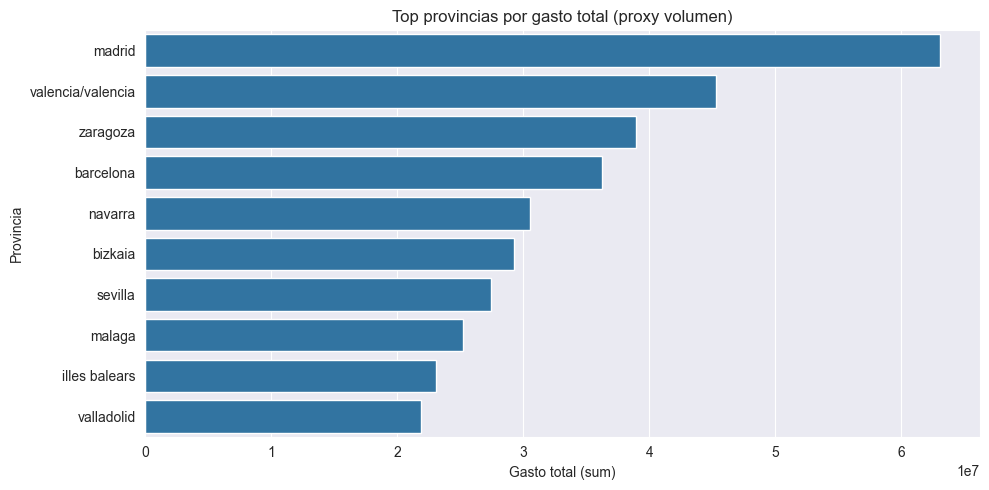

In [71]:
# Top provincias por gasto
plt.figure(figsize=(10,5))
sns.barplot(data=top_prov_gasto, x="gasto_total", y="provincia")
plt.title("Top provincias por gasto total (proxy volumen)")
plt.xlabel("Gasto total (sum)")
plt.ylabel("Provincia")
plt.tight_layout()
plt.show()

En estas provincias se genera un mayor gasto turístico agregado
El análisis del gasto total agregado por provincia permite identificar aquellos territorios donde se concentra una mayor actividad económica asociada al turismo. Provincias como Madrid, Valencia y Barcelona destacan por registrar los niveles más elevados de gasto total, lo que sugiere una alta intensidad turística y una mayor concentración de actividades de ocio y recreativas.

Es importante señalar que este indicador representa un proxy del volumen económico turístico, y no el gasto medio por turista individual. Por tanto, los valores elevados reflejan principalmente una mayor escala de actividad turística en el territorio, más que un mayor nivel de gasto unitari

# Oferta de actividades (densidad / diversidad / perfil destino)

In [72]:
# -----------------------------
# 4) Diversidad por provincia
# -----------------------------
div_prov = (df_actividades_ccaa.groupby(["comunidad_autonoma","provincia"], as_index=False)
              .agg(
                  num_categorias=("categoria", "nunique"),
                  num_subcategorias=("subcategoria", "nunique"),
                  num_productos=("producto", "nunique"),
                  registros=("categoria", "size")
              ))

display(div_prov.sort_values("num_categorias", ascending=False).head(15))

,comunidad_autonoma,provincia,num_categorias,num_subcategorias,num_productos,registros
0,andalucia,almeria,7,11,2,78
1,andalucia,cadiz,7,10,2,82
6,andalucia,malaga,7,12,2,107
10,aragon,zaragoza,7,11,2,114
5,andalucia,jaen,7,12,2,59
8,aragon,huesca,7,9,2,53
7,andalucia,sevilla,7,11,2,116
11,canarias,las palmas,7,10,2,105
46,pais vasco,araba/alava,7,11,2,80
44,illes balears,illes balears,7,12,2,129


Andalucía presenta una mayor diversidad y cobertura de actividades en el dataset, lo que permite construir itinerarios más variados.
El análisis de diversidad de actividades por provincia muestra que la comunidad autónoma de Andalucía presenta una de las coberturas más amplias y variadas del conjunto de datos. Todas sus provincias incluyen el total de categorías turísticas consideradas y un elevado número de subcategorías, lo que evidencia una oferta turística heterogénea y multifacética.
Esta diversidad permite la construcción de itinerarios personalizados en función de distintos perfiles de viaje, como turismo cultural, gastronómico, urbano, de naturaleza o mixto. En el contexto del proyecto CulturaTrip, Andalucía se identifica como un territorio con alta capacidad para la generación de rutas turísticas adaptables y de alta complejidad.

In [73]:
# -----------------------------
# 4.1) Perfil de destino (categoría dominante por provincia)
# -----------------------------
cat_dom = (df_actividades_ccaa.groupby(["provincia","categoria"], as_index=False)
             .agg(gasto=("gasto_total_promedio","sum"))
             .sort_values(["provincia","gasto"], ascending=[True, False]))

cat_dom["rank"] = cat_dom.groupby("provincia")["gasto"].rank(method="first", ascending=False)
cat_dom_top = cat_dom[cat_dom["rank"] == 1].drop(columns=["rank"])

display(cat_dom_top.head(20))

,provincia,categoria,gasto
5,a coruna,vida nocturna,4329166.32
10,albacete,vida nocturna,10791419.02
17,alicante/alacant,vida nocturna,5162546.39
24,almeria,vida nocturna,9514030.54
31,araba/alava,vida nocturna,2103936.65
38,asturias,vida nocturna,4382930.88
39,avila,otros,623535.00
47,badajoz,vida nocturna,2479042.77
54,barcelona,vida nocturna,13956706.86
58,bizkaia,paisaje naturaleza,11880233.44


La tabla refleja, para cada provincia, la categoría de actividad que concentra el mayor gasto turístico agregado. Sí se puede inferir que estas son las categorías donde el turista gasta más por provincia, dentro del dataset analizado. La vida nocturna actúa como categoría tractora de gasto en múltiples provincias, especialmente en destinos urbanos y costeros.
El análisis del gasto turístico agregado por provincia permite identificar la categoría de actividad que concentra el mayor volumen económico en cada territorio. Los resultados muestran que, en un número significativo de provincias, la categoría “vida nocturna” actúa como principal generador de gasto, especialmente en destinos urbanos y costeros.
En contraste, en provincias de carácter más rural o natural, el gasto se concentra mayoritariamente en actividades asociadas al paisaje y la naturaleza. Este patrón evidencia la existencia de perfiles territoriales diferenciados de consumo turístico, lo que resulta clave para el diseño de un sistema de recomendación adaptado a distintos tipos de viajeros y motivaciones.

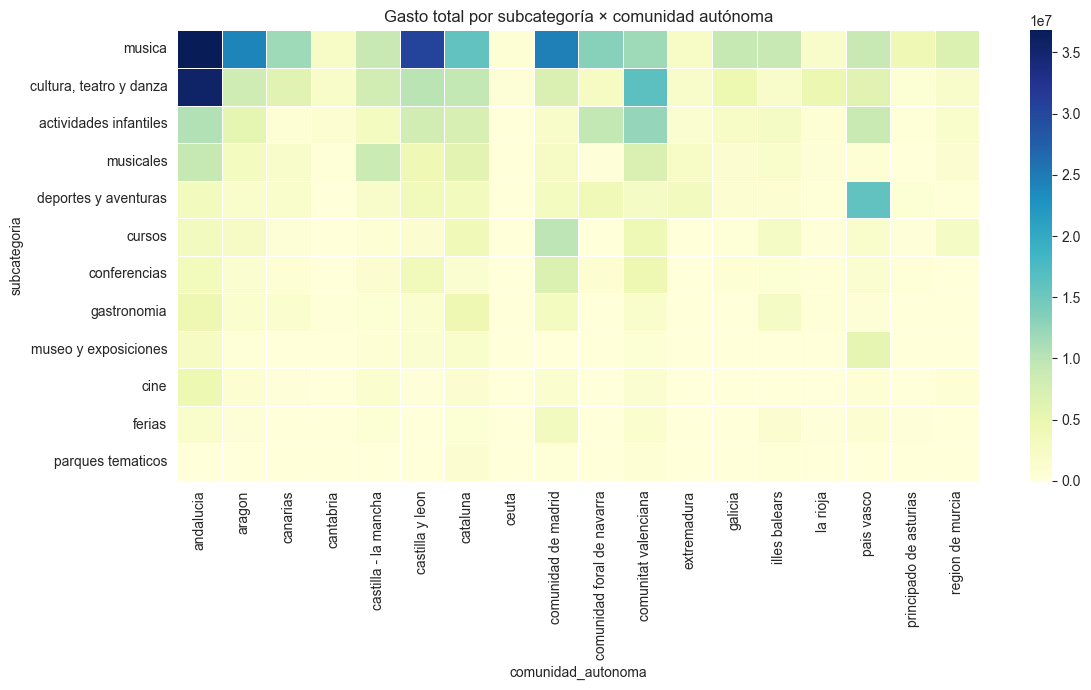

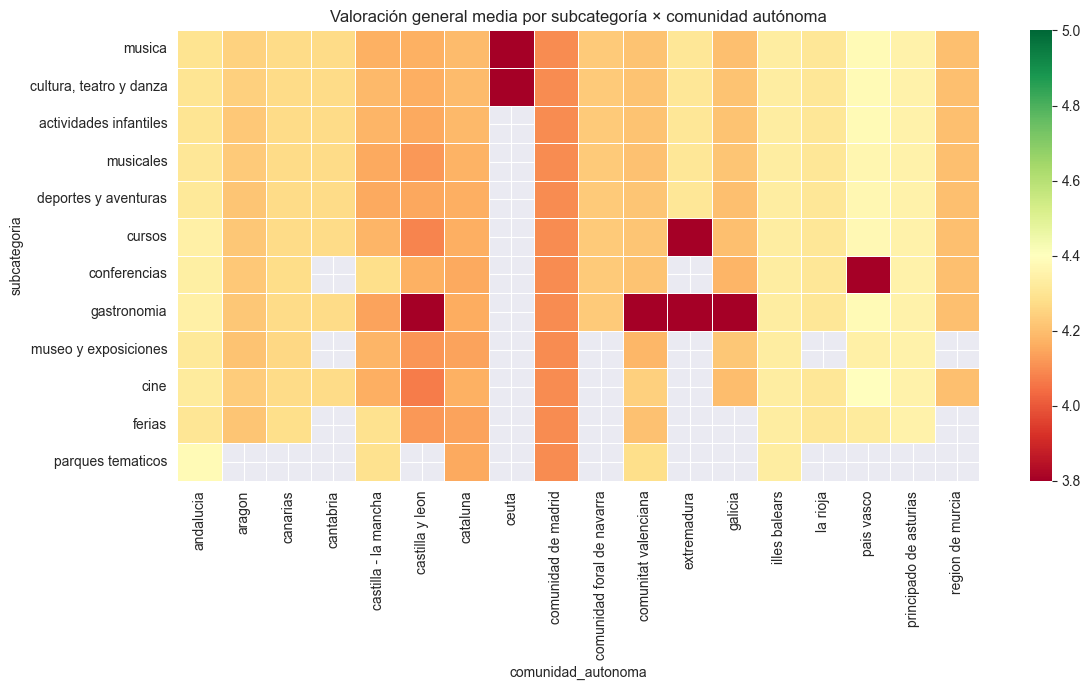

In [97]:
# -----------------------------
# 4.2) Heatmap subcategoría × comunidad (gasto y valoración)
# -----------------------------
pivot_gasto = pd.pivot_table(
    df_actividades_ccaa, index="subcategoria", columns="comunidad_autonoma",
    values="gasto_total_promedio", aggfunc="sum", fill_value=0
)

pivot_val = pd.pivot_table(
    df_actividades_ccaa, index="subcategoria", columns="comunidad_autonoma",
    values="valoracion_general_promedio", aggfunc="mean"
)

# Ordenar subcategorías por gasto total global
orden_sub = (df_actividades_ccaa.groupby("subcategoria")["gasto_total_promedio"].sum()
               .sort_values(ascending=False).index.tolist())
pivot_gasto = pivot_gasto.reindex(orden_sub)
pivot_val   = pivot_val.reindex(orden_sub)

plt.figure(figsize=(12,7))
sns.heatmap(pivot_gasto, cmap=PALETA_HEAT, linewidths=.5)
plt.title("Gasto total por subcategoría × comunidad autónoma")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,7))
sns.heatmap(pivot_val, cmap="RdYlGn", vmin=3.8, vmax=5.0, linewidths=.5)
plt.title("Valoración general media por subcategoría × comunidad autónoma")
plt.tight_layout()
# Guardar en assets

plt.savefig(ASSETS_DIR / "Gasto total por subcategoria por comunidad autónoma.png", dpi=300)
plt.show()
plt.close()

Heatmap de gasto total por subcategoría × CCAA
las que zonas más intensas indican dónde se concentra el gasto turístico por tipo de actividad
El gasto total se interpreta como un proxy de volumen económico turístico asociado a cada subcategoría, permitiendo identificar especializaciones territoriales y áreas de mayor intensidad de consumo turístico

Heatmap de valoración general media por subcategoría × CCAA
Mide la La percepción media de calidad/satisfacción del turista.
La valoración media permite introducir una dimensión cualitativa en el análisis, evidenciando que el volumen económico no siempre se traduce en mayor satisfacción percibida

El análisis conjunto del gasto total y de las valoraciones medias por subcategoría y comunidad autónoma permite identificar patrones de especialización turística, así como diferencias relevantes entre volumen económico y percepción de calidad. Los resultados evidencian que los territorios con mayor gasto no siempre presentan las mejores valoraciones, lo que refuerza la necesidad de un sistema de recomendación que combine variables económicas y cualitativas. Este enfoque resulta clave para el diseño de itinerarios personalizados y para la estimación de escenarios de ahorro dentro de la plataforma CulturaTrip.

# Coste vs valoración (calidad–precio)

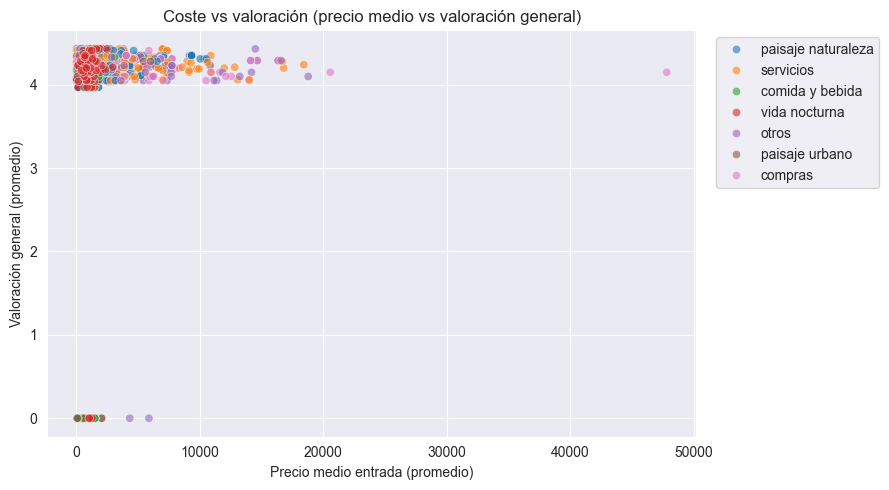

Correlación (precio vs valoración): 0.015


In [98]:
# -----------------------------
# 5) Relación coste vs valoración
# -----------------------------
df_tmp = df_actividades.dropna(subset=["precio_medio_entrada_promedio","valoracion_general_promedio"])

plt.figure(figsize=(9,5))
sns.scatterplot(
    data=df_tmp,
    x="precio_medio_entrada_promedio",
    y="valoracion_general_promedio",
    hue="categoria",
    alpha=0.6
)
plt.title("Coste vs valoración (precio medio vs valoración general)")
plt.xlabel("Precio medio entrada (promedio)")
plt.ylabel("Valoración general (promedio)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
# Guardar en assets

plt.savefig(ASSETS_DIR / "Costo vs Valoracion.png", dpi=300)
plt.show()
plt.close()

corr = df_tmp[["precio_medio_entrada_promedio","valoracion_general_promedio"]].corr().iloc[0,1]
print("Correlación (precio vs valoración):", round(corr, 3))


Eje X: precio_medio_entrada_promedio
Eje Y: valoracion_general_promedio
Color: categoría de actividad
Correlación: −0.032

No existe relación significativa entre el precio medio y la valoración general. Esto quiere decir que las actividades baratas pueden estar muy bien valoradas y las actividades caras no garantizan mejor experiencia

El análisis de la relación entre el precio medio de entrada y la valoración general muestra una correlación prácticamente nula (−0.032), lo que indica que el coste económico de una actividad no constituye un buen predictor de la percepción de calidad del turista. Este resultado sugiere que existen actividades con elevada satisfacción percibida a precios reducidos, así como experiencias de alto coste cuya valoración no difiere significativamente del promedio. Este hallazgo justifica la necesidad de un sistema de recomendación que combine variables económicas y cualitativas, en lugar de basarse únicamente en el precio.

# Estacionalidad (mes recomendado / temporada)

In [76]:
# -----------------------------
# 6) Estacionalidad general
# -----------------------------
mensual = (df_actividades.groupby("mes", as_index=False)
             .agg(
                 gasto=("gasto_total_promedio","mean"),
                 precio=("precio_medio_entrada_promedio","mean"),
                 valoracion=("valoracion_general_promedio","mean"),
                 opiniones=("total_opiniones_categoria_promedio","mean")
             ))

display(mensual)

,mes,gasto,precio,valoracion,opiniones
0,1,228963.288745,1096.154207,4.203727,37639.922509
1,2,183875.099307,1128.604927,4.190547,38935.675182
2,3,184652.864965,1192.257797,4.196888,36508.902098
3,4,198800.308728,1379.614664,4.214064,37347.229682
4,5,188445.406403,1389.339568,4.192698,36562.741007
5,6,141218.641570,1471.887645,4.163584,37609.034130
6,7,143945.370000,1581.803322,4.169446,36276.631922
7,8,149737.903754,1499.314757,4.158252,35642.229773
8,9,156898.405590,1564.253634,4.205248,35435.226708
9,10,172728.534307,1179.687611,4.201563,35473.976401


El gasto en actividades aumenta en invierno, especialmente en periodos festivos (Navidad, Año Nuevo).
El verano es más caro, aunque no necesariamente genera más gasto total agregado

El análisis temporal revela una marcada estacionalidad en los precios de las actividades, con máximos durante los meses de verano y mínimos en invierno. Sin embargo, el gasto total agregado y el volumen de opiniones alcanzan sus valores más altos en los meses invernales, especialmente en enero, febrero y diciembre. La valoración media se mantiene estable a lo largo del año, lo que indica que la satisfacción del turista no depende del momento temporal. Este resultado permite identificar meses óptimos para la planificación del viaje, maximizando la relación calidad–precio

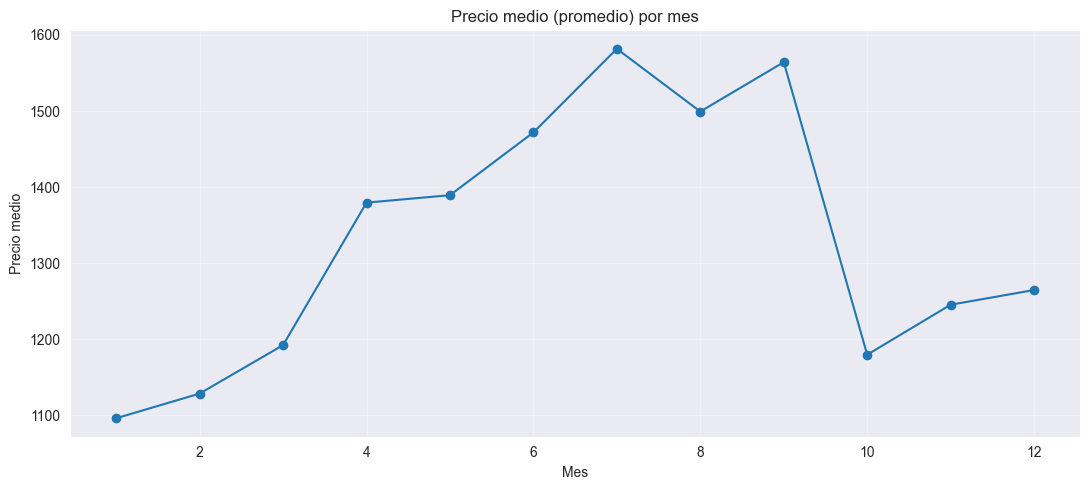

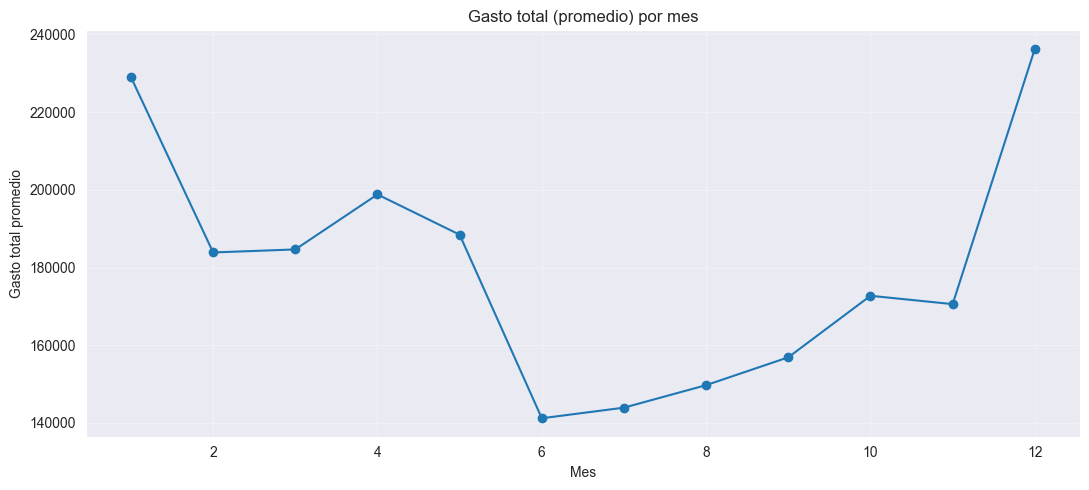

In [103]:
# Series temporales simples
plt.figure()
plt.plot(mensual["mes"], mensual["precio"], marker="o")
plt.title("Precio medio (promedio) por mes")
plt.xlabel("Mes")
plt.ylabel("Precio medio")
plt.grid(True, alpha=0.3)
plt.tight_layout()
# Guardar en assets

plt.savefig(ASSETS_DIR / "Precio medio (promedio) por mes.png", dpi=300)
plt.show()
plt.close()

plt.figure()
plt.plot(mensual["mes"], mensual["gasto"], marker="o")
plt.title("Gasto total (promedio) por mes")
plt.xlabel("Mes")
plt.ylabel("Gasto total promedio")
plt.grid(True, alpha=0.3)
plt.tight_layout()
# Guardar en assets

plt.savefig(ASSETS_DIR / "Gasto total promedio.png", dpi=300)
plt.show()
plt.close()

estos gráficos permiten identificar claramente los meses en los que se produce mayor y menor gasto turístico.
El análisis temporal de los precios y del gasto turístico evidencia una marcada estacionalidad en el comportamiento del turista en España. Mientras que los precios medios alcanzan sus máximos durante los meses de verano, el gasto total agregado se concentra especialmente en períodos festivos como Semana Santa y Navidad. Este desacople entre precio y gasto refuerza la necesidad de incorporar variables temporales en el sistema de recomendación, permitiendo estimaciones presupuestarias más realistas y personalizadas según el momento del año.

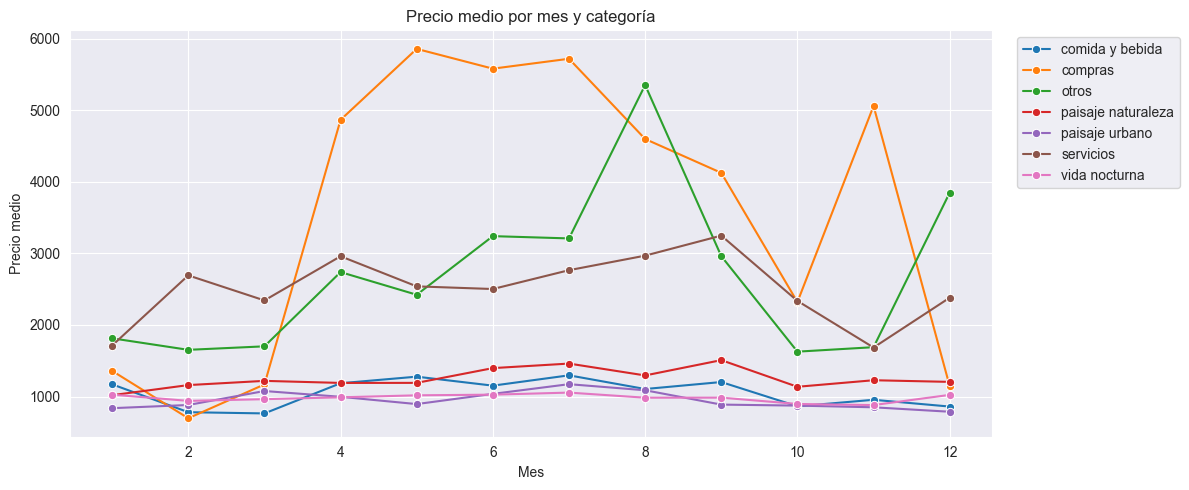

In [100]:
# -----------------------------
# 6.1) Estacionalidad por categoría (precio)
# -----------------------------
mensual_cat = (df_actividades.groupby(["mes","categoria"], as_index=False)
                 .agg(precio=("precio_medio_entrada_promedio","mean"),
                      gasto=("gasto_total_promedio","mean")))

plt.figure(figsize=(12,5))
sns.lineplot(data=mensual_cat, x="mes", y="precio", hue="categoria", marker="o")
plt.title("Precio medio por mes y categoría")
plt.xlabel("Mes")
plt.ylabel("Precio medio")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
# Guardar en assets

plt.savefig(ASSETS_DIR / "Precio medio por mes y categoria.png", dpi=300)
plt.show()
plt.close()

este gráfico permite identificar en qué meses se produce un mayor gasto (precio medio) por tipo de actividad.
El análisis del precio medio por mes y categoría evidencia que la estacionalidad impacta de forma desigual según el tipo de actividad turística. Mientras categorías como comida y bebida o vida nocturna presentan una evolución relativamente estable a lo largo del año, otras como compras y actividades especiales muestran picos de gasto muy pronunciados en períodos concretos. Este comportamiento refuerza la necesidad de incorporar la dimensión temporal y tipológica en el sistema de estimación presupuestaria propuesto.

# Escenarios de ahorro (mes/provincia más barata)

In [79]:
# -----------------------------
# 7) Ahorro potencial por mes (robusto con percentiles)
# -----------------------------
def resumen_percentiles(s):
    return pd.Series({
        "p25": s.quantile(0.25),
        "p50": s.quantile(0.50),
        "p75": s.quantile(0.75),
        "mean": s.mean()
    })

ahorro_mes = (
    df_actividades
    .groupby("mes")["precio_medio_entrada_promedio"]
    .apply(resumen_percentiles)
    .unstack()              # 👈 convierte p25/p50/p75/mean en columnas
    .reset_index()
)

ahorro_mes["ahorro_potencial_%"] = (
    (ahorro_mes["p75"] - ahorro_mes["p25"]) / ahorro_mes["p75"] * 100
)

display(ahorro_mes.sort_values("ahorro_potencial_%", ascending=False))

,mes,p25,p50,p75,mean,ahorro_potencial_%
5,6,500.0000,996.000,1617.5000,1471.887645,69.088099
8,9,515.7500,991.250,1644.5000,1564.253634,68.637884
9,10,439.6650,902.750,1365.1000,1179.687611,67.792469
3,4,515.6350,978.350,1484.2000,1379.614664,65.258388
1,2,469.9675,882.585,1299.1250,1128.604927,63.824305
4,5,578.0000,979.485,1533.1675,1389.339568,62.300271
2,3,546.3350,892.000,1390.5450,1192.257797,60.710729
10,11,497.7475,839.970,1246.3825,1245.401382,60.064627
11,12,549.0700,888.500,1354.7500,1264.701498,59.470751
0,1,542.2500,910.500,1313.6500,1096.154207,58.721882


Se logro identificar los meses en los que se ahorra mas.
Qué porcentaje del precio “caro” (p75) puede evitarse si el usuario elige actividades en el rango económico (p25) del mismo mes. El usuario puede reducir entre un 57% y un 69% del coste de actividades si elige opciones optimizadas por el sistema.

El análisis de percentiles del precio medio de actividades por mes permite estimar el potencial de ahorro derivado de la toma de decisiones informada. Los resultados muestran que existe una elevada dispersión de precios durante ciertos meses del año, especialmente en junio, septiembre y octubre, donde el ahorro potencial supera el 65%. Este hallazgo respalda la viabilidad de un sistema de recomendación como CulturaTrip, capaz de guiar al usuario hacia alternativas con una mejor relación calidad-precio sin comprometer la experiencia cultural.

In [80]:
# -----------------------------
# 7.1) Ahorro potencial por provincia (precio)
# -----------------------------
ahorro_prov = (
    df_actividades
    .groupby("provincia")["precio_medio_entrada_promedio"]
    .apply(resumen_percentiles)
    .unstack()              # 👈 convierte p25/p50/p75/mean en columnas
    .reset_index()
)

ahorro_prov["ahorro_potencial_%"] = (
    (ahorro_prov["p75"] - ahorro_prov["p25"]) / ahorro_prov["p75"] * 100
)

display(ahorro_prov.sort_values("ahorro_potencial_%", ascending=False))




,provincia,p25,p50,p75,mean,ahorro_potencial_%
22,guadalajara,267.0000,784.500,1347.0000,894.407838,80.178174
15,ceuta,223.5000,715.000,1067.9150,731.688261,79.071368
5,asturias,595.8000,968.000,2830.2000,2269.941481,78.948484
7,badajoz,189.0000,632.000,894.9650,646.630448,78.881856
18,cuenca,325.0000,910.200,1243.5000,1356.552093,73.864093
32,madrid,657.7700,1145.760,2476.5225,2164.897540,73.439773
39,salamanca,319.3350,642.090,1169.7500,775.280886,72.700577
46,toledo,522.8600,871.780,1886.0000,1215.104923,72.276776
20,girona,382.5200,837.940,1279.7250,1159.204211,70.109203
23,huelva,424.9175,540.700,1392.0000,1038.263529,69.474318


Esta tabla identifica las provincias con mayor margen de variabilidad de precios
demuestra las provincias donde se puede ahorrar mas y se puede hacer varios paquetes de ahorro segun el presupuesto del usuario.
El análisis por percentiles a nivel provincial permite identificar territorios con alta dispersión de precios en actividades turísticas, lo que se traduce en un elevado potencial de optimización del gasto. Estas provincias resultan especialmente adecuadas para la construcción de itinerarios personalizados y paquetes de ahorro, ya que el mismo destino puede adaptarse a distintos perfiles presupuestarios sin comprometer la experiencia turística.

# Cobertura de valoraciones y “confianza” (opiniones)

In [81]:
# -----------------------------
# 8) Cobertura de valoraciones
# -----------------------------
coverage = df_actividades["hay_valoracion"].value_counts(dropna=False).rename_axis("hay_valoracion").reset_index(name="conteo")
display(coverage)

# Nulos por provincia-categoria
nulos_val = (df_actividades.assign(sin_val=np.where(df_actividades["valoracion_general_promedio"].isna(), 1, 0))
               .groupby(["provincia","categoria"], as_index=False)["sin_val"].mean()
               .rename(columns={"sin_val":"prop_sin_valoracion"}))

display(nulos_val.sort_values("prop_sin_valoracion", ascending=False).head(20))

,hay_valoracion,conteo
0,True,3567
1,False,42


,provincia,categoria,prop_sin_valoracion
0,a coruna,comida y bebida,0.0
1,a coruna,otros,0.0
2,a coruna,paisaje naturaleza,0.0
3,a coruna,paisaje urbano,0.0
4,a coruna,servicios,0.0
5,a coruna,vida nocturna,0.0
6,albacete,comida y bebida,0.0
7,albacete,paisaje naturaleza,0.0
8,albacete,paisaje urbano,0.0
9,albacete,servicios,0.0


In [82]:
# -----------------------------
# 8.1) Confianza por número de opiniones
# -----------------------------
# Ejemplo de bins (ajusta según distribución real)
df_actividades["opiniones_bin"] = pd.cut(
    df_actividades["total_opiniones_categoria_promedio"],
    bins=[-1, 10, 50, 200, 1000, 1e9],
    labels=["0-10", "11-50", "51-200", "201-1000", "1000+"]
)

val_conf = (
    df_actividades
    .groupby("opiniones_bin", as_index=False, observed=True)
    .agg(
        valoracion=("valoracion_general_promedio", "mean"),
        n=("valoracion_general_promedio", "count")
    )
)

display(val_conf)

,opiniones_bin,valoracion,n
0,0-10,2.190909,88
1,11-50,4.249595,74
2,51-200,4.241749,183
3,201-1000,4.227753,445
4,1000+,4.241493,2819


La cobertura de valoraciones es prácticamente completa, lo que permite utilizar métricas de satisfacción sin necesidad de imputaciones agresivas ni supuestos fuertes.

El análisis de la relación entre número de opiniones y valoración media evidencia una elevada estabilidad en las puntuaciones, lo que sugiere consistencia en la percepción turística. No obstante, el volumen de opiniones se incorpora como un factor de confianza estadística, permitiendo ponderar las recomendaciones sin penalizar destinos con menor visibilidad.

# ¿Qué relación existe entre tipo de producto y gasto promedio?

In [83]:
# Agrupar por producto y calcular métricas promedio
df_producto_gasto = (
    df_actividades
    .groupby("producto", as_index=False)
    .agg(
        gasto_total_promedio=("gasto_total_promedio", "mean"),
        precio_medio_entrada_promedio=("precio_medio_entrada_promedio", "mean"),
        total_registros=("producto", "count")
    )
    .sort_values("gasto_total_promedio", ascending=False)
)

df_producto_gasto

,producto,gasto_total_promedio,precio_medio_entrada_promedio,total_registros
1,espectaculos,211797.444544,1243.688139,2203
0,actividades,127128.309957,1479.069851,1406


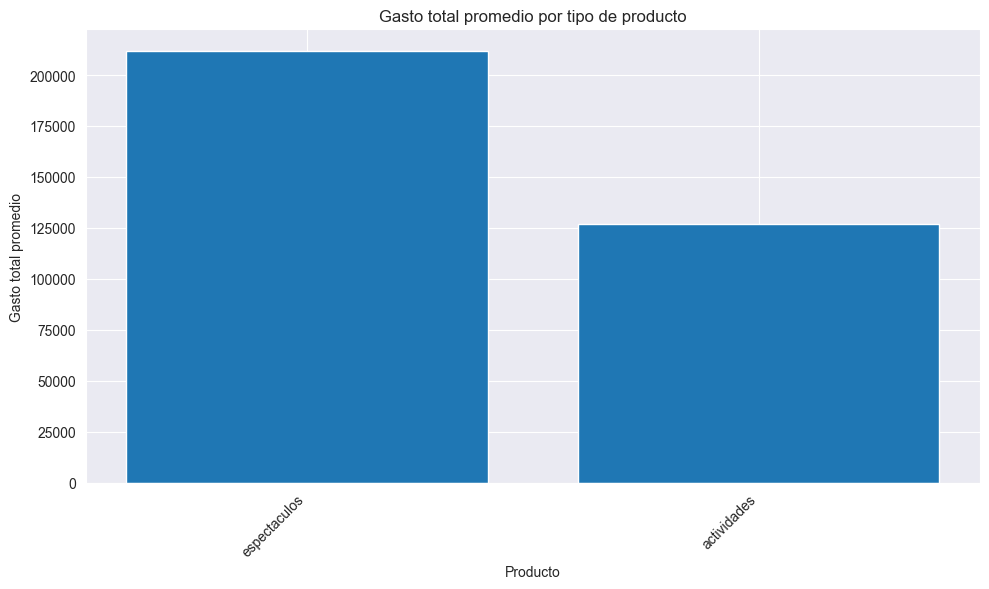

In [104]:
# gasto promedio por tipo de producto (bar chart)
plt.figure(figsize=(10,6))
plt.bar(
    df_producto_gasto["producto"],
    df_producto_gasto["gasto_total_promedio"]
)
plt.title("Gasto total promedio por tipo de producto")
plt.xlabel("Producto")
plt.ylabel("Gasto total promedio")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
# Guardar en assets

plt.savefig(ASSETS_DIR / "Gasto total promedio por tipo de producto.png", dpi=300)
plt.show()
plt.close()

Los espectáculos presentan un gasto total promedio superior al de otras actividades, lo que indica que este tipo de producto implica un mayor desembolso económico por parte del turista.

El análisis muestra que el producto “espectáculos” presenta un gasto total promedio significativamente superior al de “actividades”, lo que sugiere que este tipo de experiencia concentra un mayor nivel de gasto, posiblemente asociado a eventos, entradas con mayor precio o consumo complementario.

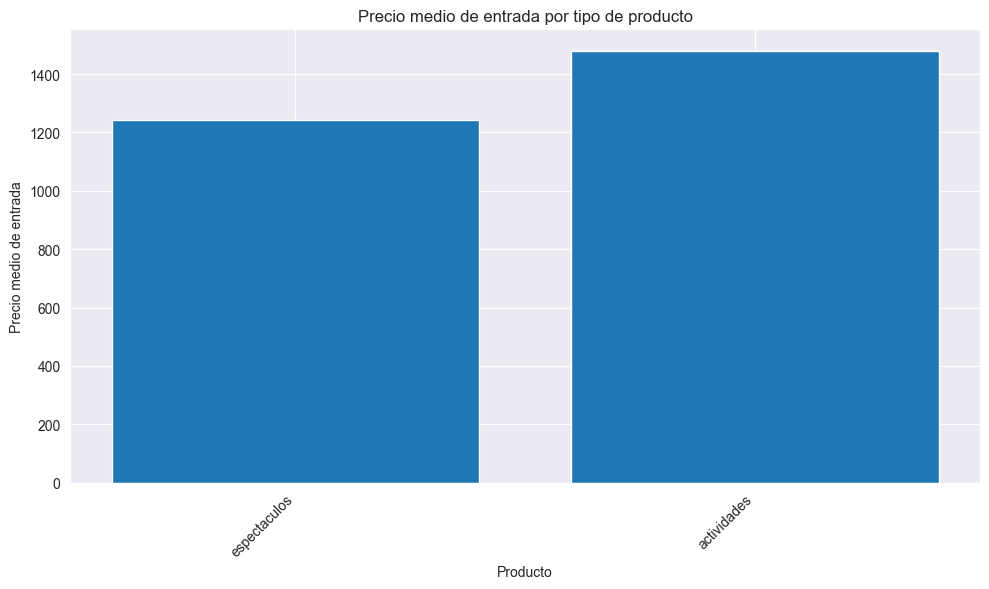

In [101]:
# precio medio de entrada por tipo de producto
plt.figure(figsize=(10,6))
plt.bar(
    df_producto_gasto["producto"],
    df_producto_gasto["precio_medio_entrada_promedio"]
)
plt.title("Precio medio de entrada por tipo de producto")
plt.xlabel("Producto")
plt.ylabel("Precio medio de entrada")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
# Guardar en assets

plt.savefig(ASSETS_DIR / "Precio medio de entrada por tipo de producto.png", dpi=300)
plt.show()
plt.close()

Las actividades presentan un precio medio de entrada superior al de los espectáculos, lo que indica que, cuando existe un acceso mediante entrada, el costo promedio asociado a las actividades es mayor.

El análisis del precio medio de entrada por tipo de producto muestra que las actividades presentan un valor promedio superior al de los espectáculos. Este resultado sugiere que las actividades analizadas suelen implicar un mayor costo de acceso, lo cual puede estar asociado a experiencias que requieren inscripción, ticket o participación guiada.

<Figure size 1200x600 with 0 Axes>

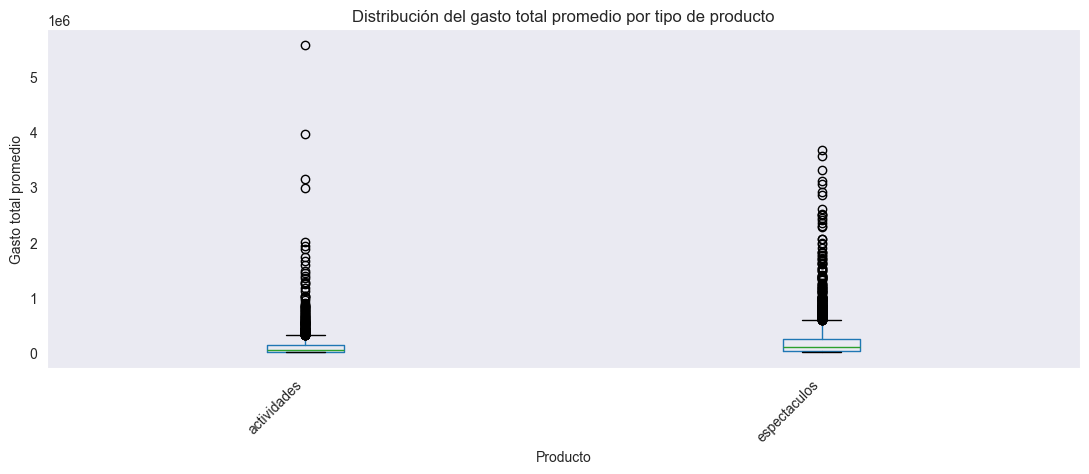

In [102]:
plt.figure(figsize=(12,6))
df_actividades.boxplot(
    column="gasto_total_promedio",
    by="producto",
    grid=False
)
plt.title("Distribución del gasto total promedio por tipo de producto")
plt.suptitle("")
plt.xlabel("Producto")
plt.ylabel("Gasto total promedio")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
# Guardar en assets

plt.savefig(ASSETS_DIR / "Distribucion de gasto total promedio por tipo de producto.png", dpi=300)
plt.show()
plt.close()

La distribución del gasto total promedio por tipo de producto muestra una elevada dispersión en ambos casos, con presencia de valores atípicos. Las actividades presentan una mayor variabilidad y outliers más elevados, lo que indica la existencia de experiencias con gastos significativamente superiores al promedio, mientras que los espectáculos muestran una distribución más concentrada.

In [87]:
df_producto_gasto.style.format({
    "gasto_total_promedio": "{:.2f}",
    "precio_medio_entrada_promedio": "{:.2f}"
})

,producto,gasto_total_promedio,precio_medio_entrada_promedio,total_registros
1,espectaculos,211797.44,1243.69,2203
0,actividades,127128.31,1479.07,1406


El análisis conjunto del gasto total promedio, el precio medio de entrada y el volumen de registros por tipo de producto muestra diferencias claras entre espectáculos y actividades. Los espectáculos presentan un gasto total promedio significativamente mayor, lo que sugiere un mayor desembolso agregado asociado a este tipo de experiencias. Por el contrario, las actividades registran un precio medio de entrada superior, lo que indica que el costo de acceso tiene un mayor peso relativo en este tipo de producto. Asimismo, los espectáculos concentran un mayor número de registros, lo que refleja una mayor presencia de este producto en el conjunto de datos analizado.